# BÀI TẬP LỚN MACHINE LEARNING
## 00 — EDA Tổng hợp Tuần 1 / Data Phase

Notebook này kế thừa theo thứ tự: **Trí — kiểm định chất lượng dữ liệu**, **Danh — phân tích phân bố**, sau đó **Nhân — tương quan, quan hệ đa biến, leakage và kết luận tích hợp**. Dataset đúng là `data/raw/bank.csv`, được trích từ `data/raw/archive (2).zip`; biến mục tiêu thống nhất là `deposit`.

> Các cell Markdown và code của Trí/Danh được giữ nguyên tối đa. Chỉ các thay đổi tương thích hoặc sửa lỗi đã ghi rõ trong notebook thành phần mới được áp dụng.

# PHẦN A — NỘI DUNG KẾ THỪA TỪ TRÍ

# BÀI TẬP LỚN MACHINE LEARNING
## Notebook 01: Kiểm định Cấu trúc & Chất lượng Dữ liệu Thô (Data Quality & Inspection)

**Mục tiêu của Notebook:**
1. Đọc và khám phá tập dữ liệu thô từ `data/raw/bank.csv`.
2. Trích xuất các thông số kỹ thuật: kích thước dữ liệu, danh sách các cột, kiểu dữ liệu (`int64`, `float64`, `object`/`str`).
3. Đánh giá chất lượng dữ liệu:
   - Thống kê tỷ lệ khuyết thiếu dữ liệu (Missing Values) chuẩn (`NaN`) và dạng ngầm định (`'unknown'`).
   - Xuất biểu đồ ma trận Missing Values lưu vào `figures/01_missing_values.png`.
   - Kiểm tra dữ liệu trùng lặp (Duplicated Rows).
   - Phát hiện các giá trị bất thường (giá trị âm, định dạng chuỗi bất thường).
4. Phân tích độ phân tán và phát hiện ngoại lai (Outliers) qua Biểu đồ hộp (Boxplot) & phương pháp IQR.
5. Tổng hợp bảng thông số cấu trúc dữ liệu phục vụ **Mục 2.1 của Báo cáo**.


**Ghi chú tích hợp:** Nội dung, trình tự và cách trình bày của Trí được giữ nguyên. Chỉ đổi đường dẫn sang `data/raw/bank.csv`, sửa ký tự thừa làm notebook không chạy, khai báo bảng báo cáo vốn phụ thuộc hidden state, và tách mã sentinel `pdays = -1` khỏi phép sàng lọc IQR.


### 1. Khởi tạo Thư viện và Thiết lập Môi trường
Import các thư viện phân tích dữ liệu cơ bản (`pandas`, `numpy`) và trực quan hóa (`matplotlib`, `seaborn`).
Sử dụng `pathlib.Path` để đường dẫn luôn chính xác dù notebook được chạy từ thư mục gốc hay thư mục `notebooks/`.


In [1]:
import os
import sys
from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị bảng dữ liệu của pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Cấu hình thẩm mỹ đồ thị seaborn
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Xác định đường dẫn gốc của dự án (Project Root)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank.csv"
FIGURES_PATH = PROJECT_ROOT / "figures"

# Đảm bảo thư mục figures tồn tại
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Figures path: {FIGURES_PATH}")


Project root: E:\Downloads\BTL_ML_git
Dataset path: E:\Downloads\BTL_ML_git\data\raw\bank.csv
Figures path: E:\Downloads\BTL_ML_git\figures


### 2. Đọc Dữ liệu Thô từ file CSV
Đọc file `data/raw/bank.csv` vào DataFrame của pandas và quan sát các dòng dữ liệu mẫu đầu tiên.


In [2]:
# Đọc file dữ liệu thô
df = pd.read_csv(DATA_PATH)

print(f"Tải dữ liệu thành công! Tổng số dòng: {len(df):,}, Tổng số cột: {len(df.columns)}")
# Xem 5 dòng đầu tiên
df.head()


Tải dữ liệu thành công! Tổng số dòng: 11,162, Tổng số cột: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### 3. Trích xuất Thông số Kỹ thuật & Cấu trúc Dữ liệu
Trích xuất:
- Tổng số dòng và tổng số cột (`shape`).
- Tên các cột và kiểu dữ liệu (`dtypes`).
- Phân loại thành nhóm biến số lượng (Numerical) và biến phân loại (Categorical).


In [3]:
# 1. Kích thước tập dữ liệu
n_rows, n_cols = df.shape
print("=== THÔNG SỐ TỔNG QUAN ===")
print(f"- Tổng số dòng quan sát (Rows):    {n_rows:,}")
print(f"- Tổng số cột thuộc tính (Cols):    {n_cols}")

# 2. Phân loại kiểu dữ liệu
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print()
print(f"- Số lượng biến số (Numerical):          {len(num_cols)} cột -> {num_cols}")
print(f"- Số lượng biến định danh (Categorical): {len(cat_cols)} cột -> {cat_cols}")

# 3. Bảng chi tiết kiểu dữ liệu từng cột
tech_info = pd.DataFrame({
    'Tên Cột': df.columns,
    'Kiểu Dữ Liệu (Dtype)': [str(df[col].dtype) for col in df.columns],
    'Phân Loại': ['Numerical' if col in num_cols else 'Categorical' for col in df.columns],
    'Bộ Nhớ Sử Dụng': [f"{df[col].memory_usage(deep=True) / 1024:.1f} KB" for col in df.columns]
})
tech_info


=== THÔNG SỐ TỔNG QUAN ===
- Tổng số dòng quan sát (Rows):    11,162
- Tổng số cột thuộc tính (Cols):    17

- Số lượng biến số (Numerical):          7 cột -> ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
- Số lượng biến định danh (Categorical): 10 cột -> ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


,Tên Cột,Kiểu Dữ Liệu (Dtype),Phân Loại,Bộ Nhớ Sử Dụng
0,age,int64,Numerical,87.3 KB
1,job,object,Categorical,636.2 KB
2,marital,object,Categorical,608.4 KB
3,education,object,Categorical,624.8 KB
4,default,object,Categorical,556.2 KB
5,balance,int64,Numerical,87.3 KB
6,housing,object,Categorical,561.2 KB
7,loan,object,Categorical,557.5 KB
8,contact,object,Categorical,619.9 KB
9,day,int64,Numerical,87.3 KB


### 4. Đánh giá Dữ liệu Khuyết Thiếu (Missing Values)
Trong phân tích thực tế:
1. **Khuyết thiếu tường minh (Explicit NA/NaN):** Các ô dữ liệu rỗng hoàn toàn hoặc giá trị `NaN`, `null`.
2. **Khuyết thiếu ngầm định (Implicit Missing):** Trong tập dữ liệu này (Bank Marketing), các giá trị thiếu ở biến phân loại thường được hệ thống ghi nhận bằng chuỗi `'unknown'`.

Chúng ta sẽ thống kê cả 2 dạng để có cái nhìn toàn diện và chính xác nhất.


In [4]:
# 1. Đếm missing tường minh (NaN/null)
explicit_missing = df.isnull().sum()

# 2. Đếm missing ngầm định (chuỗi 'unknown' ở các cột phân loại)
implicit_missing = {}
for col in df.columns:
    if col in cat_cols:
        count = (df[col].astype(str).str.strip().str.lower() == 'unknown').sum()
        implicit_missing[col] = count
    else:
        implicit_missing[col] = 0

# 3. Tổng hợp thành bảng thống kê khuyết thiếu
missing_df = pd.DataFrame({
    'Cột': df.columns,
    'Số lượng NaN': explicit_missing.values,
    'Tỷ lệ NaN (%)': (explicit_missing.values / len(df) * 100).round(2),
    'Số lượng "unknown"': [implicit_missing[c] for c in df.columns],
    'Tỷ lệ "unknown" (%)': ([round(implicit_missing[c] / len(df) * 100, 2) for c in df.columns]),
    'Tổng khuyết thiếu (NaN + unknown)': explicit_missing.values + np.array([implicit_missing[c] for c in df.columns]),
    'Tổng tỷ lệ thiếu (%)': ((explicit_missing.values + np.array([implicit_missing[c] for c in df.columns])) / len(df) * 100).round(2)
})

# Sắp xếp giảm dần theo tổng tỷ lệ thiếu
missing_df = missing_df.sort_values(by='Tổng tỷ lệ thiếu (%)', ascending=False).reset_index(drop=True)
missing_df


,Cột,Số lượng NaN,Tỷ lệ NaN (%),"Số lượng ""unknown""","Tỷ lệ ""unknown"" (%)",Tổng khuyết thiếu (NaN + unknown),Tổng tỷ lệ thiếu (%)
0,poutcome,0,0.0,8326,74.59,8326,74.59
1,contact,0,0.0,2346,21.02,2346,21.02
2,education,0,0.0,497,4.45,497,4.45
3,job,0,0.0,70,0.63,70,0.63
4,age,0,0.0,0,0.00,0,0.00
5,default,0,0.0,0,0.00,0,0.00
6,balance,0,0.0,0,0.00,0,0.00
7,housing,0,0.0,0,0.00,0,0.00
8,marital,0,0.0,0,0.00,0,0.00
9,loan,0,0.0,0,0.00,0,0.00


### 5. Trực quan hóa và Xuất Biểu đồ Ma trận Missing Values
Tạo **biểu đồ cột (Barplot)** thể hiện phần trăm dữ liệu thiếu/unknown trên từng cột.

File ảnh sẽ được tự động lưu vào `figures/01_missing_values.png`.


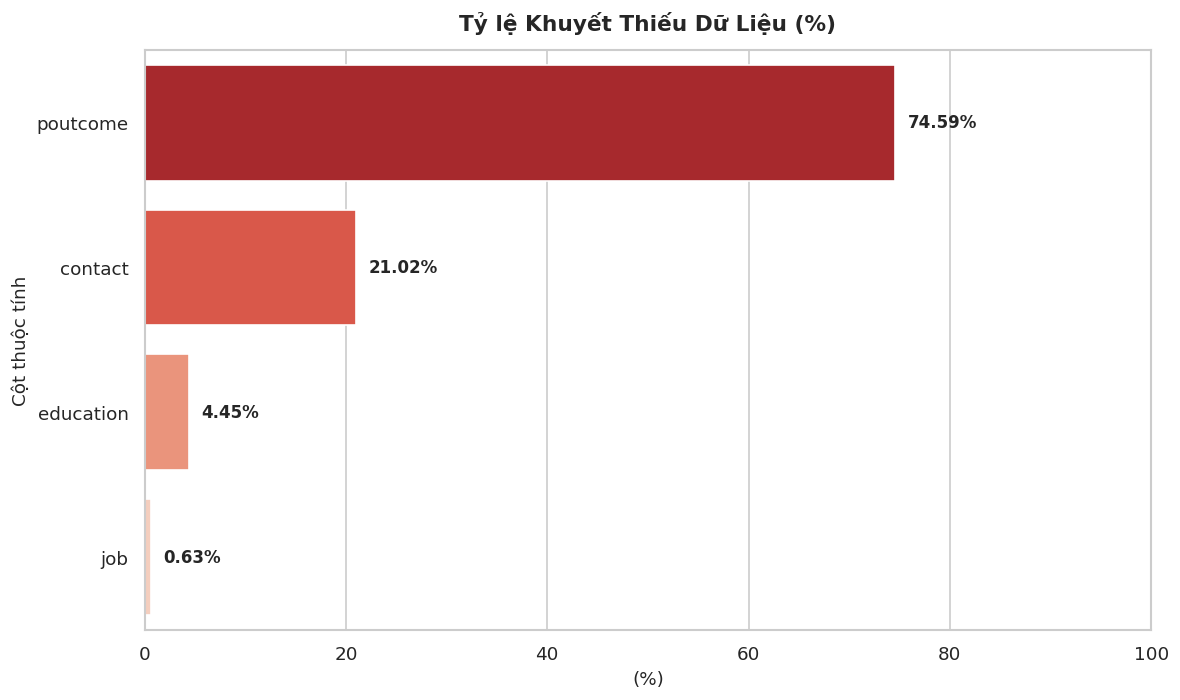

saved at E:\Downloads\BTL_ML_git\figures\01_missing_values.png


In [5]:
# Tạo bản sao thay thế 'unknown' thành np.nan để trực quan hóa khuyết thiếu
df_plot_missing = df.replace('unknown', np.nan)

fig, ax = plt.subplots(figsize=(10, 6))

# Tỷ lệ khuyết thiếu của các cột có giá trị thiếu
cols_with_missing = missing_df[missing_df['Tổng tỷ lệ thiếu (%)'] > 0]

sns.barplot(
    data=cols_with_missing,
    x='Tổng tỷ lệ thiếu (%)',
    y='Cột',
    hue='Cột',
    palette='Reds_r',
    legend=False,
    ax=ax
)
ax.set_title('Tỷ lệ Khuyết Thiếu Dữ Liệu (%)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('(%)', fontsize=11)
ax.set_ylabel('Cột thuộc tính', fontsize=11)
ax.set_xlim(0, 100)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.2f}%", 
                (width + 1.2, p.get_y() + p.get_height() / 2.),
                va='center', fontweight='bold', fontsize=10)

plt.tight_layout()

# Lưu hình ảnh vào thư mục figures
out_image_path = FIGURES_PATH / "01_missing_values.png"
plt.savefig(out_image_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"saved at {out_image_path}")

### 6. Kiểm tra Dữ liệu Trùng Lặp (Duplicated Rows)
Đếm và trích xuất các dòng bị trùng lặp hoàn toàn trên tất cả các thuộc tính.


In [6]:
# Đếm số dòng trùng lặp hoàn toàn
duplicate_count = df.duplicated().sum()
print("=== KIỂM TRA TRÙNG LẶP DỮ LIỆU ===")
print(f"- Số dòng bị trùng lặp hoàn toàn: {duplicate_count}")
print(f"- Tỷ lệ trùng lặp: {duplicate_count / len(df) * 100:.2f}%")

if duplicate_count > 0:
    print("\nDanh sách các dòng trùng lặp:")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns[:3])))
else:
    print("Tập dữ liệu sạch")


=== KIỂM TRA TRÙNG LẶP DỮ LIỆU ===
- Số dòng bị trùng lặp hoàn toàn: 0
- Tỷ lệ trùng lặp: 0.00%
Tập dữ liệu sạch


### 7. Phát hiện Các Giá trị Bất Thường (Anomalies & Inconsistencies)
Chúng ta tiến hành kiểm tra:
1. **Giá trị âm vô lý ở các cột số:** Các cột như `age` (tuổi), `duration` (thời lượng gọi), `campaign` (số lần gọi), `day` (ngày trong tháng) không thể nhận giá trị âm.
   - *Lưu ý nghiệp vụ:* 
     - Cột `balance` (số dư tài khoản): Giá trị âm biểu thị tình trạng thấu chi (overdraft) hoặc nợ tài khoản - điều này hoàn toàn hợp lệ trong thực tế ngân hàng.
     - Cột `pdays`: Giá trị `-1` là mã quy ước chuẩn của UCI Machine Learning biểu thị khách hàng chưa từng được liên hệ trong các chiến dịch trước đó.
2. **Giá trị chuỗi bất thường:** Kiểm tra khoảng trắng thừa (leading/trailing whitespace) hoặc các ký tự dị thường (ví dụ: `admin.` có dấu chấm ở cuối).


In [7]:
print("=== 1. KIỂM TRA GIÁ TRỊ ÂM Ở CÁC CỘT SỐ ===")
neg_summary = []
for col in num_cols:
    neg_mask = df[col] < 0
    neg_cnt = neg_mask.sum()
    min_val = df[col].min()
    neg_summary.append({
        'Tên cột': col,
        'Giá trị Min': min_val,
        'Số lượng âm': neg_cnt,
        'Tỷ lệ âm (%)': f"{neg_cnt / len(df) * 100:.2f}%",
        'Đánh giá': (
            'Hợp lệ (Thấu chi tài khoản)' if col == 'balance' and neg_cnt > 0 else
            'Quy ước chuẩn UCI (-1: chưa liên hệ)' if col == 'pdays' and neg_cnt > 0 else
            'Bất thường cần xử lý' if neg_cnt > 0 else 'Bình thường (Không có âm)'
        )
    })

neg_df = pd.DataFrame(neg_summary)
display(neg_df)

print()
print("=== 2. KIỂM TRA ĐỊNH DẠNG VÀ KHOẢNG TRẮNG Ở CỘT PHÂN LOẠI ===")
for col in cat_cols:
    unique_vals = df[col].unique().tolist()
    has_whitespace = any(isinstance(v, str) and (v != v.strip()) for v in unique_vals)
    print(f"Cột [{col}]: {len(unique_vals)} giá trị duy nhất")
    print(f"   - Mẫu giá trị: {unique_vals[:6]}")
    if has_whitespace:
        print(f"   [CẢNH BÁO] Cột {col} chứa khoảng trắng thừa ở đầu/cuối!")
    if col == 'job' and 'admin.' in unique_vals:
        print(f"   [GHI CHÚ] Cột 'job' có giá trị 'admin.' (kèm dấu chấm cuối chuỗi).")


=== 1. KIỂM TRA GIÁ TRỊ ÂM Ở CÁC CỘT SỐ ===


,Tên cột,Giá trị Min,Số lượng âm,Tỷ lệ âm (%),Đánh giá
0,age,18,0,0.00%,Bình thường (Không có âm)
1,balance,-6847,688,6.16%,Hợp lệ (Thấu chi tài khoản)
2,day,1,0,0.00%,Bình thường (Không có âm)
3,duration,2,0,0.00%,Bình thường (Không có âm)
4,campaign,1,0,0.00%,Bình thường (Không có âm)
5,pdays,-1,8324,74.57%,Quy ước chuẩn UCI (-1: chưa liên hệ)
6,previous,0,0,0.00%,Bình thường (Không có âm)



=== 2. KIỂM TRA ĐỊNH DẠNG VÀ KHOẢNG TRẮNG Ở CỘT PHÂN LOẠI ===
Cột [job]: 12 giá trị duy nhất
   - Mẫu giá trị: ['admin.', 'technician', 'services', 'management', 'retired', 'blue-collar']
   [GHI CHÚ] Cột 'job' có giá trị 'admin.' (kèm dấu chấm cuối chuỗi).
Cột [marital]: 3 giá trị duy nhất
   - Mẫu giá trị: ['married', 'single', 'divorced']
Cột [education]: 4 giá trị duy nhất
   - Mẫu giá trị: ['secondary', 'tertiary', 'primary', 'unknown']
Cột [default]: 2 giá trị duy nhất
   - Mẫu giá trị: ['no', 'yes']
Cột [housing]: 2 giá trị duy nhất
   - Mẫu giá trị: ['yes', 'no']
Cột [loan]: 2 giá trị duy nhất
   - Mẫu giá trị: ['no', 'yes']
Cột [contact]: 3 giá trị duy nhất
   - Mẫu giá trị: ['unknown', 'cellular', 'telephone']
Cột [month]: 12 giá trị duy nhất
   - Mẫu giá trị: ['may', 'jun', 'jul', 'aug', 'oct', 'nov']
Cột [poutcome]: 4 giá trị duy nhất
   - Mẫu giá trị: ['unknown', 'other', 'failure', 'success']
Cột [deposit]: 2 giá trị duy nhất
   - Mẫu giá trị: ['yes', 'no']


### 8. Định vị Điểm Dị Biệt (Outliers) bằng Biểu đồ Hộp (Boxplot)
Các cột dạng số có độ biến động lớn như `balance`, `duration`, `campaign`, `pdays`, `previous`, `age` sẽ được vẽ biểu đồ hộp (Boxplot) để định vị các điểm ngoại lai.
Đồng thời, áp dụng quy tắc **IQR (Interquartile Range)**:
- $IQR = Q_3 - Q_1$
- Ngưỡng dưới: $Lower = Q_1 - 1.5 	imes IQR$
- Ngưỡng trên: $Upper = Q_3 + 1.5 	imes IQR$

**Điều chỉnh kỹ thuật tối thiểu:** Với `pdays`, giá trị `-1` là mã sentinel “chưa từng liên hệ”, không phải số ngày. Vì vậy biểu đồ và IQR của riêng biến này chỉ dùng các bản ghi `pdays >= 0`; dữ liệu gốc không bị thay đổi.


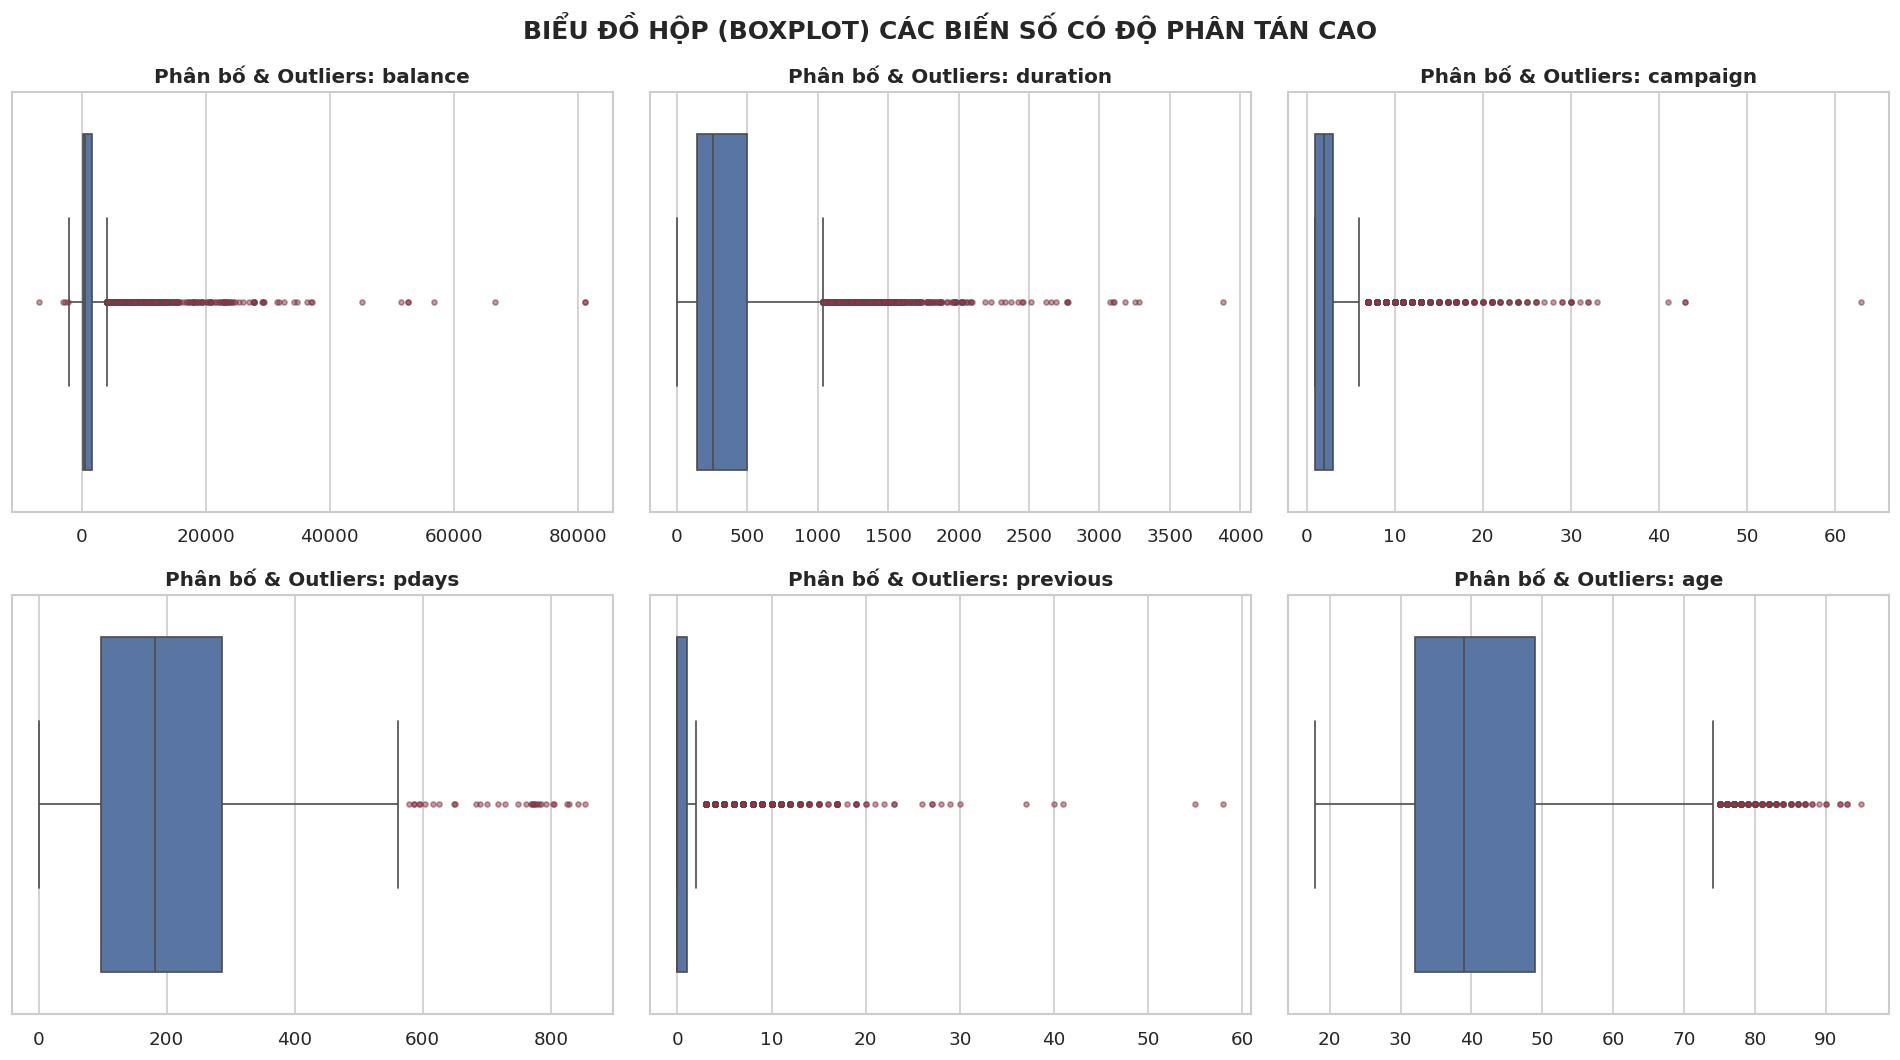

,Thuộc tính,Q1 (25%),Median (50%),Q3 (75%),IQR,Ngưỡng dưới,Ngưỡng trên,Số lượng Outlier,Tỷ lệ Outlier (%)
0,balance,122.0,550.0,1708.0,1586.0,-2257.0,4087.0,1055,9.45%
1,duration,138.0,255.0,496.0,358.0,-399.0,1033.0,636,5.70%
2,campaign,1.0,2.0,3.0,2.0,-2.0,6.0,601,5.38%
3,pdays,98.0,182.0,286.0,188.0,-184.0,568.0,32,1.13%
4,previous,0.0,0.0,1.0,1.0,-1.5,2.5,1258,11.27%
5,age,32.0,39.0,49.0,17.0,6.5,74.5,171,1.53%


In [8]:
# Chọn các cột số để vẽ Boxplot
plot_num_cols = ['balance', 'duration', 'campaign', 'pdays', 'previous', 'age']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(plot_num_cols):
    values = df.loc[df[col] >= 0, col] if col == 'pdays' else df[col]
    sns.boxplot(
        x=values,
        ax=axes[i],
        color='#4C72B0',
        flierprops={'marker': 'o', 'markersize': 3, 'markerfacecolor': 'crimson', 'alpha': 0.5}
    )
    axes[i].set_title(f"Phân bố & Outliers: {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle("BIỂU ĐỒ HỘP (BOXPLOT) CÁC BIẾN SỐ CÓ ĐỘ PHÂN TÁN CAO", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()

# Lưu hình ảnh boxplot vào figures
boxplot_img_path = FIGURES_PATH / "01_outliers_boxplots.png"
plt.savefig(boxplot_img_path, dpi=300, bbox_inches='tight')
plt.show()

# Thống kê chi tiết số lượng Outliers theo phương pháp IQR
outlier_records = []
for col in plot_num_cols:
    values = df.loc[df[col] >= 0, col] if col == 'pdays' else df[col]
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_count = ((values < lower_bound) | (values > upper_bound)).sum()
    
    outlier_records.append({
        'Thuộc tính': col,
        'Q1 (25%)': q1,
        'Median (50%)': values.median(),
        'Q3 (75%)': q3,
        'IQR': iqr,
        'Ngưỡng dưới': round(lower_bound, 2),
        'Ngưỡng trên': round(upper_bound, 2),
        'Số lượng Outlier': outlier_count,
        'Tỷ lệ Outlier (%)': f"{outlier_count / len(values) * 100:.2f}%"
    })

outlier_summary_df = pd.DataFrame(outlier_records)
outlier_summary_df


### 9. Bảng Tổng hợp Cấu trúc Dữ liệu phục vụ Báo cáo (Mục 2.1)
Bảng tổng hợp toàn bộ 17 thuộc tính với các thông số:
- **Tên biến**
- **Kiểu dữ liệu**
- **Tỷ lệ missing %** (bao gồm cả `NaN` và `unknown`)
- **Số lượng unique**
- **Diễn giải ý nghĩa nghiệp vụ**


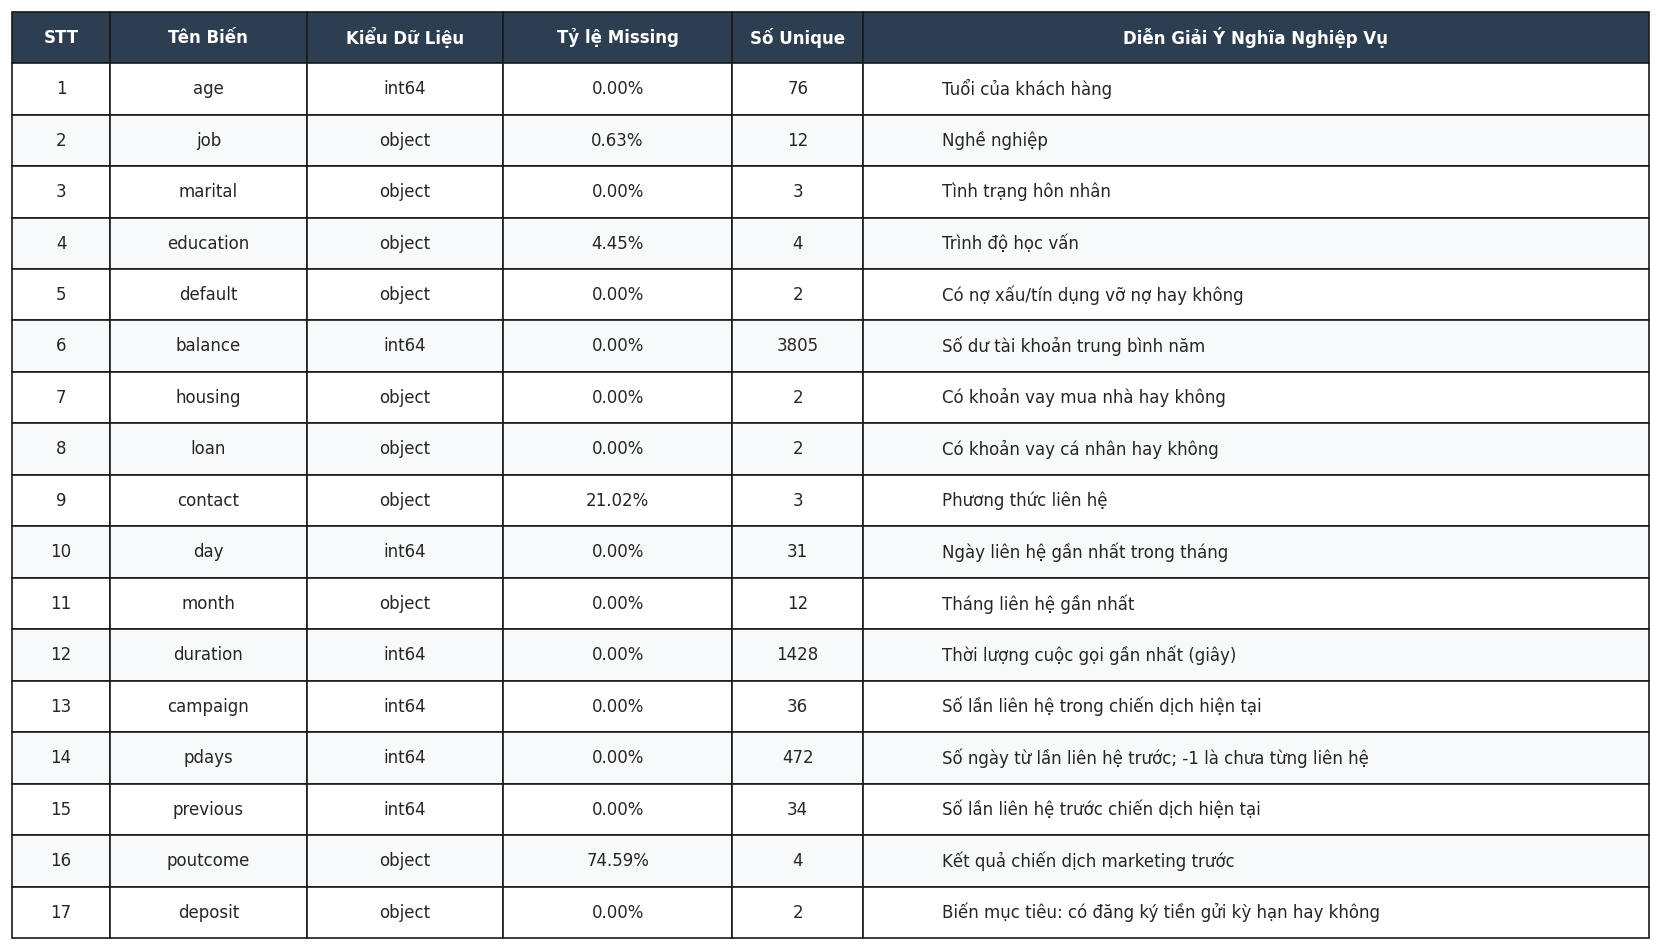

Đã xuất và lưu bảng báo cáo thành công tại: E:\Downloads\BTL_ML_git\figures\02_data_overview_report.png


In [9]:
# Khai báo bảng ngay trong notebook để loại bỏ phụ thuộc hidden state.
business_meanings = {
    'age': 'Tuổi của khách hàng',
    'job': 'Nghề nghiệp',
    'marital': 'Tình trạng hôn nhân',
    'education': 'Trình độ học vấn',
    'default': 'Có nợ xấu/tín dụng vỡ nợ hay không',
    'balance': 'Số dư tài khoản trung bình năm',
    'housing': 'Có khoản vay mua nhà hay không',
    'loan': 'Có khoản vay cá nhân hay không',
    'contact': 'Phương thức liên hệ',
    'day': 'Ngày liên hệ gần nhất trong tháng',
    'month': 'Tháng liên hệ gần nhất',
    'duration': 'Thời lượng cuộc gọi gần nhất (giây)',
    'campaign': 'Số lần liên hệ trong chiến dịch hiện tại',
    'pdays': 'Số ngày từ lần liên hệ trước; -1 là chưa từng liên hệ',
    'previous': 'Số lần liên hệ trước chiến dịch hiện tại',
    'poutcome': 'Kết quả chiến dịch marketing trước',
    'deposit': 'Biến mục tiêu: có đăng ký tiền gửi kỳ hạn hay không',
}
missing_lookup = missing_df.set_index('Cột')['Tổng tỷ lệ thiếu (%)']
report_2_1_df = pd.DataFrame({
    'STT': range(1, len(df.columns) + 1),
    'Tên Biến': df.columns,
    'Kiểu Dữ Liệu': [str(df[col].dtype) for col in df.columns],
    'Tỷ lệ Missing': [f"{missing_lookup[col]:.2f}%" for col in df.columns],
    'Số Unique': [df[col].nunique(dropna=False) for col in df.columns],
    'Diễn Giải Ý Nghĩa Nghiệp Vụ': [business_meanings[col] for col in df.columns],
})

import matplotlib.pyplot as plt

# 1. Cấu hình kích thước ảnh và tỷ lệ chiều rộng cho từng cột
# (Thứ tự tương ứng với các cột: STT, Tên Biến, Kiểu Dữ Liệu, Tỷ lệ Missing, Số Unique, Diễn Giải)
col_widths = [0.06, 0.12, 0.12, 0.14, 0.08, 0.48] 

fig_height = max(4, len(report_2_1_df) * 0.4 + 1.2)
fig, ax = plt.subplots(figsize=(14, fig_height))
ax.axis('off')
ax.axis('tight')

# 2. Đưa thêm tham số colWidths vào hàm table
table = ax.table(
    cellText=report_2_1_df.values,
    colLabels=report_2_1_df.columns,
    colWidths=col_widths,  # <-- Tự động phân chia chiều rộng cột tại đây
    cellLoc='center',
    loc='center'
)

# 3. Tinh chỉnh giao diện bảng
table.auto_set_font_size(False)
table.set_fontsize(10)

scale_factor_y = 1.5
for (row, col), cell in table.get_celld().items():
    cell.set_height(0.04 * scale_factor_y)
    
    # Căn lề trái riêng cho cột "Diễn Giải Ý Nghĩa Nghiệp Vụ" (cột cuối cùng) để dễ đọc
    if col == len(report_2_1_df.columns) - 1 and row > 0:
        cell.set_text_props(ha='left', va='center')
        # Thêm padding nhẹ bên trái cho đỡ sát mép khung
    
    if row == 0:
        cell.set_facecolor('#2c3e50')  # Màu nền tiêu đề (Xanh đậm)
        cell.set_text_props(weight='bold', color='white', ha='center')
    else:
        cell.set_facecolor('#f8f9fa' if row % 2 == 0 else '#ffffff')

plt.tight_layout()

# 4. Lưu hình ảnh vào thư mục figures
out_image_path = FIGURES_PATH / "02_data_overview_report.png"
plt.savefig(out_image_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Đã xuất và lưu bảng báo cáo thành công tại: {out_image_path}")

# PHẦN B — NỘI DUNG KẾ THỪA TỪ DANH

**Ghi chú tích hợp:** Toàn bộ mã, biểu đồ, nhận xét và văn phong phân tích phân bố của Danh được giữ nguyên. Thay đổi duy nhất là đường dẫn tệp từ `data/raw/dataset.csv` sang `data/raw/bank.csv`, là CSV đúng được trích từ `archive (2).zip`.


**Điều chỉnh tích hợp bắt buộc:** Cell import/đọc CSV của Danh được hợp nhất với phần setup của Trí để notebook tổng hợp chỉ đọc dữ liệu một lần. Các khai báo cột, kiểm tra schema, cấu hình biểu đồ và phần hiển thị của Danh được giữ lại dưới đây.

In [10]:
# Phần setup riêng của Danh, dùng lại df đã được Trí đọc ở trên.
ROOT = PROJECT_ROOT
FIGURE_DIR = FIGURES_PATH
target_col = 'deposit'

numerical_cols = [
    'age', 'balance', 'day', 'duration',
    'campaign', 'pdays', 'previous'
]

categorical_cols = [
    'job', 'marital', 'education',
    'default', 'housing', 'loan',
    'contact', 'month', 'poutcome'
]

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False
})

expected_columns = numerical_cols + categorical_cols + [target_col]
assert set(df.columns) == set(expected_columns), 'Tên cột không khớp.'
assert df[target_col].notna().all(), 'Biến mục tiêu có giá trị thiếu.'
assert set(df[target_col].unique()) == {'no', 'yes'}, 'Nhãn không hợp lệ.'
for col in numerical_cols:
    assert pd.api.types.is_numeric_dtype(df[col]), f'{col} không phải kiểu số.'
assert df['pdays'].dropna().ge(-1).all(), 'Có pdays nhỏ hơn -1 cần kiểm tra.'

print(f'Kích thước: {df.shape[0]:,} dòng × {df.shape[1]} cột')
print(f'Đặc trưng số: {len(numerical_cols)}')
print(f'Đặc trưng phân loại: {len(categorical_cols)}')
print(f'Tổng giá trị thiếu (NaN): {df.isna().sum().sum()}')
print(f'Số dòng trùng hoàn toàn: {df.duplicated().sum()}')

display(df.head())
display(df.dtypes.to_frame('dtype'))

Kích thước: 11,162 dòng × 17 cột
Đặc trưng số: 7
Đặc trưng phân loại: 9
Tổng giá trị thiếu (NaN): 0
Số dòng trùng hoàn toàn: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


,dtype
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


,count,percentage
deposit,,
no,5873,52.62
yes,5289,47.38


Tỷ số lớp đông / lớp ít: 1.110:1
Chênh lệch số mẫu: 584
Chênh lệch tỷ lệ: 5.23 điểm phần trăm


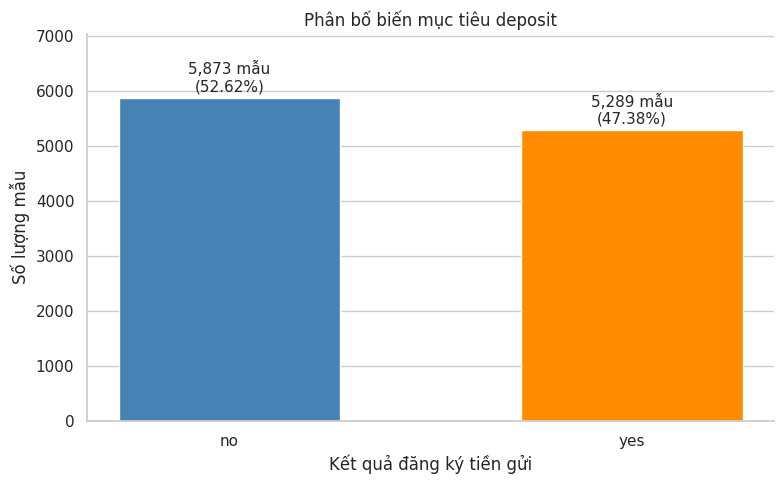

In [11]:
target_counts = (
    df[target_col]
    .value_counts()
    .reindex(["no", "yes"])
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_counts / target_counts.sum() * 100
})

imbalance_ratio = target_counts.max() / target_counts.min()

percentage_gap = (
    target_summary["percentage"].max()
    - target_summary["percentage"].min()
)

display(target_summary.round(2))

print(f"Tỷ số lớp đông / lớp ít: {imbalance_ratio:.3f}:1")
print(f"Chênh lệch số mẫu: {target_counts.max() - target_counts.min():,}")
print(f"Chênh lệch tỷ lệ: {percentage_gap:.2f} điểm phần trăm")

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    target_counts.index,
    target_counts.values,
    color=["steelblue", "darkorange"],
    width=0.55
)

for bar, count in zip(bars, target_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + target_counts.max() * 0.02,
        f"{count:,} mẫu\n({count / len(df):.2%})",
        ha="center",
        fontsize=11
    )

ax.set_title("Phân bố biến mục tiêu deposit")
ax.set_xlabel("Kết quả đăng ký tiền gửi")
ax.set_ylabel("Số lượng mẫu")
ax.set_ylim(0, target_counts.max() * 1.2)
ax.grid(axis="x", visible=False)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "02_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Nhận xét phân bố biến mục tiêu

Lớp `no` có 5.873 mẫu (52,62%), lớp `yes` có 5.289 mẫu (47,38%).
Chênh lệch là 584 mẫu, tương ứng 5,23 điểm phần trăm tính từ tỷ lệ
chưa làm tròn. Tỷ số lớp đông trên lớp ít khoảng 1,110:1.

Như vậy, biến mục tiêu tương đối cân bằng, không có mất cân bằng
nhãn nghiêm trọng trong tập dữ liệu này.

Tỷ lệ trên chỉ mô tả bộ dữ liệu đang khảo sát; chưa thể suy rộng
thành tỷ lệ đăng ký thực tế của toàn bộ khách hàng ngân hàng.

In [12]:
# Thống kê trạng thái pdays trên toàn bộ dữ liệu.
pdays_status_counts = pd.Series({
    "Chưa từng liên hệ (-1)": df["pdays"].eq(-1).sum(),
    "Đã từng liên hệ (>= 0)": df["pdays"].ge(0).sum(),
    "Thiếu dữ liệu (NaN)": df["pdays"].isna().sum()
})

pdays_status_summary = pd.DataFrame({
    "count": pdays_status_counts,
    "percentage": pdays_status_counts / len(df) * 100
})

print("Trạng thái pdays — tỷ lệ tính trên toàn bộ dữ liệu:")
display(pdays_status_summary.round(2))

# Bản sao phục vụ thống kê; không sửa df gốc.
numeric_data = df[numerical_cols].copy()

numeric_data["pdays"] = numeric_data["pdays"].where(
    numeric_data["pdays"].ge(0)
)

# describe() và skew() tự bỏ qua NaN.
numerical_summary = numeric_data.describe().T
numerical_summary["skewness"] = numeric_data.skew()

# Đổi nhãn hàng để tránh nhầm phạm vi thống kê.
numerical_summary = numerical_summary.rename(
    index={"pdays": "pdays (>= 0; đã liên hệ)"}
)

print("Thống kê các đặc trưng số:")
display(numerical_summary.round(3))

print(
    "Lưu ý: count của pdays chỉ đếm số bản ghi có số ngày hợp lệ; "
    "không phải tổng số bản ghi của bộ dữ liệu."
)

Trạng thái pdays — tỷ lệ tính trên toàn bộ dữ liệu:


,count,percentage
Chưa từng liên hệ (-1),8324,74.57
Đã từng liên hệ (>= 0),2838,25.43
Thiếu dữ liệu (NaN),0,0.00


Thống kê các đặc trưng số:


,count,mean,std,min,25%,50%,75%,max,skewness
age,11162.0,41.232,11.913,18.0,32.0,39.0,49.0,95.0,0.863
balance,11162.0,1528.539,3225.413,-6847.0,122.0,550.0,1708.0,81204.0,8.225
day,11162.0,15.658,8.421,1.0,8.0,15.0,22.0,31.0,0.111
duration,11162.0,371.994,347.128,2.0,138.0,255.0,496.0,3881.0,2.144
campaign,11162.0,2.508,2.722,1.0,1.0,2.0,3.0,63.0,5.546
pdays (>= 0; đã liên hệ),2838.0,204.818,122.197,1.0,98.0,182.0,286.0,854.0,1.275
previous,11162.0,0.833,2.292,0.0,0.0,0.0,1.0,58.0,7.335


Lưu ý: count của pdays chỉ đếm số bản ghi có số ngày hợp lệ; không phải tổng số bản ghi của bộ dữ liệu.


### Cách diễn giải thống kê

- `count`: số giá trị được sử dụng để tính thống kê.
- `mean`: trung bình cộng.
- `std`: độ lệch chuẩn mẫu.
- `25%`, `50%`, `75%`: Q1, trung vị và Q3.
- `skewness`: độ bất đối xứng của phân bố.

Quy ước mô tả tham khảo:
- |skewness| < 0,5: gần đối xứng.
- 0,5 ≤ |skewness| ≤ 1: lệch vừa.
- |skewness| > 1: lệch mạnh.

Skewness dương biểu thị lệch phải; skewness âm biểu thị lệch trái.
Skewness gần 0 không chứng minh phân bố chuẩn.

Riêng `pdays`, bảng chỉ sử dụng 2.838 bản ghi có giá trị >= 0.
Các mã -1 vẫn được giữ trong dữ liệu gốc và thống kê riêng theo trạng thái.

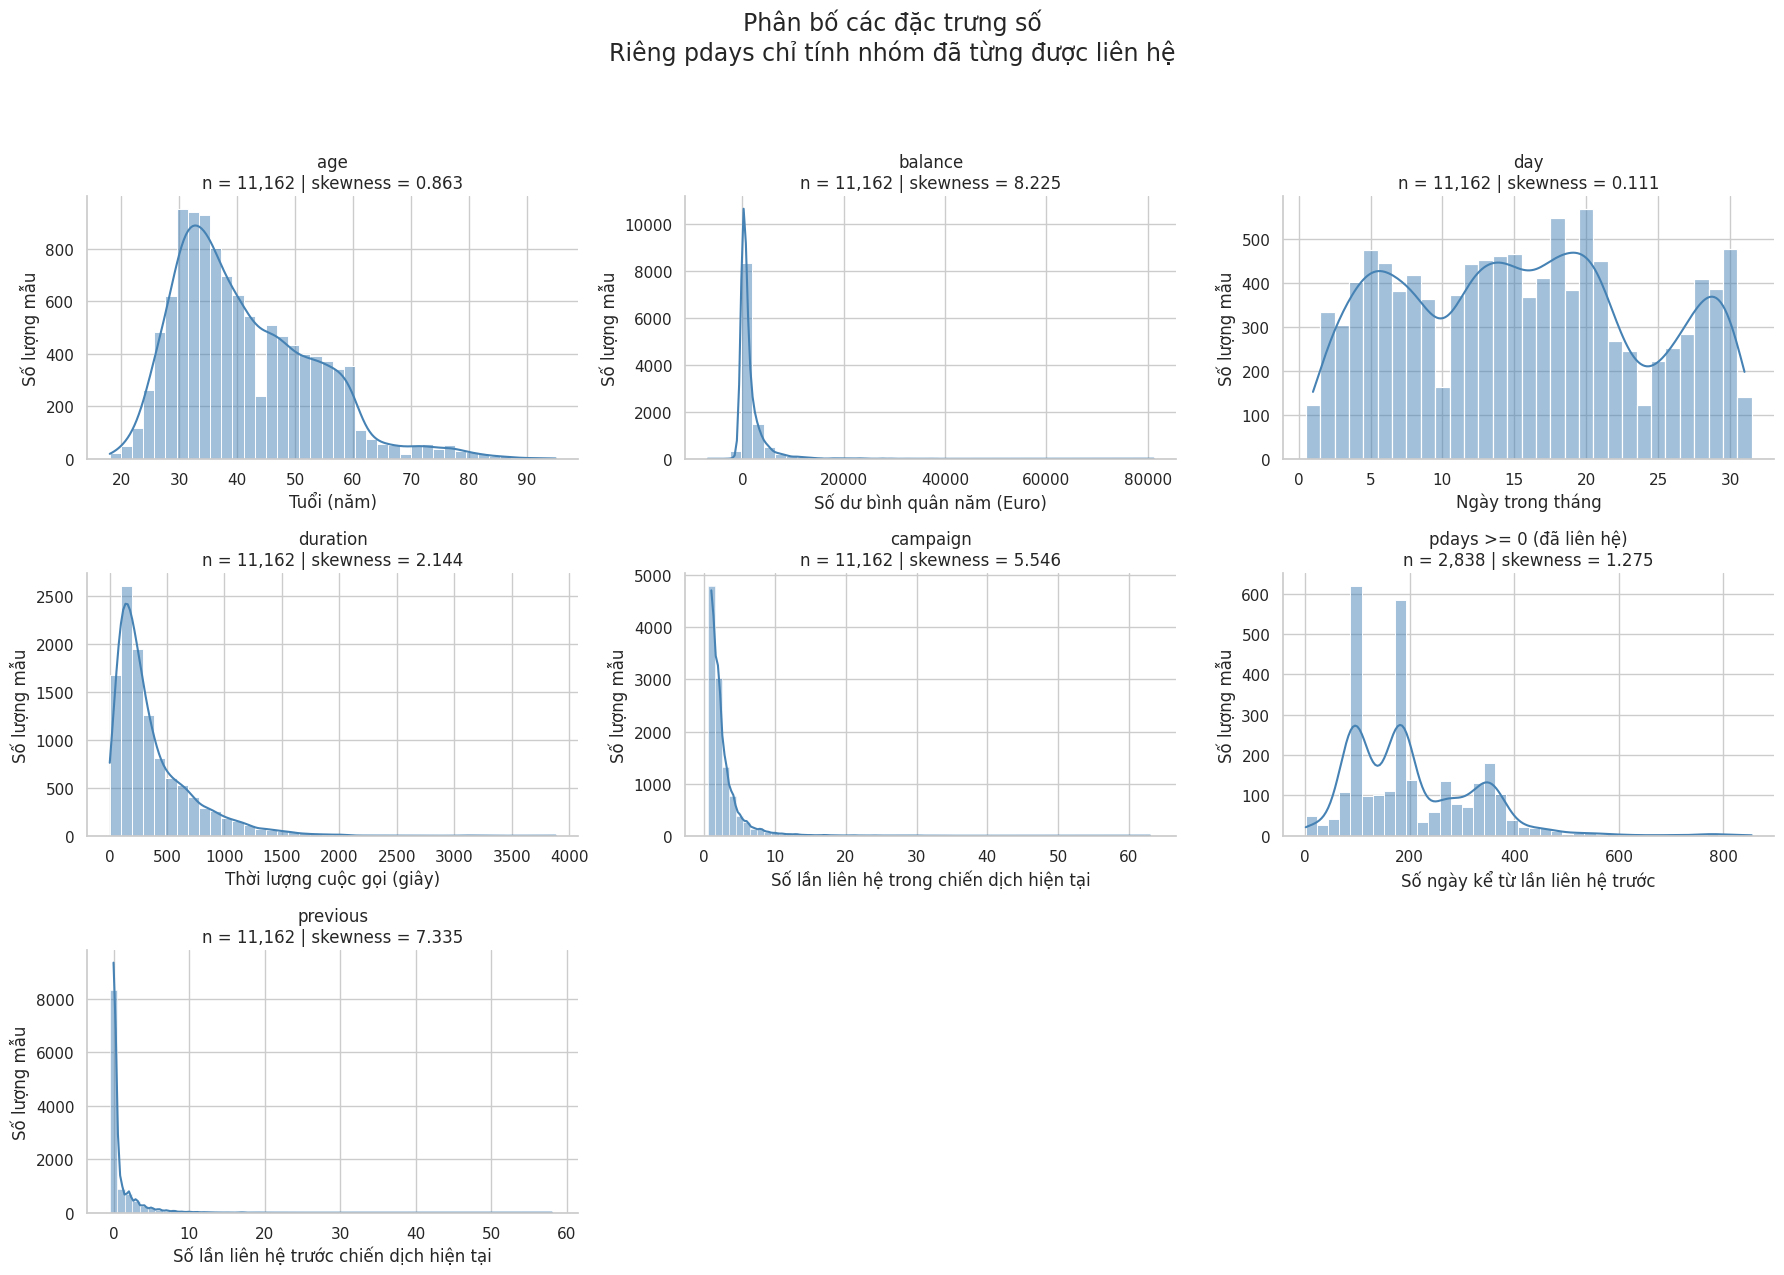

In [13]:
axis_labels = {
    "age": "Tuổi (năm)",
    "balance": "Số dư bình quân năm (Euro)",
    "day": "Ngày trong tháng",
    "duration": "Thời lượng cuộc gọi (giây)",
    "campaign": "Số lần liên hệ trong chiến dịch hiện tại",
    "pdays": "Số ngày kể từ lần liên hệ trước",
    "previous": "Số lần liên hệ trước chiến dịch hiện tại"
}

integer_bins_cols = {"day", "campaign", "previous"}

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()

for ax, col in zip(axes, numerical_cols):
    values = numeric_data[col].dropna()

    # Mỗi số nguyên có một bin riêng cho các biến này.
    if col in integer_bins_cols:
        bins = np.arange(
            values.min() - 0.5,
            values.max() + 1.5,
            1
        )
    else:
        bins = 40

    sns.histplot(
        x=values,
        bins=bins,
        kde=True,
        kde_kws={"cut": 0},
        color="steelblue",
        ax=ax
    )

    label = "pdays >= 0 (đã liên hệ)" if col == "pdays" else col

    ax.set_title(
        f"{label}\nn = {len(values):,} | skewness = {values.skew():.3f}"
    )
    ax.set_xlabel(axis_labels[col])
    ax.set_ylabel("Số lượng mẫu")

# Ẩn hai ô không sử dụng.
for ax in axes[len(numerical_cols):]:
    ax.set_visible(False)

fig.suptitle(
    "Phân bố các đặc trưng số\n"
    "Riêng pdays chỉ tính nhóm đã từng được liên hệ",
    fontsize=17
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(
    FIGURE_DIR / "04_feature_histograms.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Nhận xét phân bố các đặc trưng số

- `age` lệch phải vừa, với skewness khoảng 0,863. Trung vị là 39 tuổi,
  Q1 và Q3 lần lượt là 32 và 49 tuổi.
- `balance` lệch phải rất mạnh, với skewness khoảng 8,225.
  Trung bình 1.528,54 Euro cao hơn đáng kể trung vị 550 Euro.
  Dữ liệu có số dư âm và một số số dư lớn, lên tới 81.204 Euro.
- `duration` lệch phải mạnh, với skewness khoảng 2,144.
  Trung vị là 255 giây, trung bình khoảng 371,99 giây.
- `campaign` và `previous` lệch phải mạnh, với skewness lần lượt
  khoảng 5,546 và 7,335. Phần lớn quan sát có số lần liên hệ thấp,
  trong khi một số bản ghi có số lần liên hệ rất cao.
- `day` có skewness khoảng 0,111, cho thấy ít bất đối xứng.
  Tuy nhiên, đây là biến ngày trong tháng, có miền rời rạc 1–31;
  không thể kết luận phân bố chuẩn chỉ từ skewness nhỏ.
- `pdays` trên nhóm đã được liên hệ có skewness khoảng 1,275,
  cho thấy lệch phải.

Histogram và KDE dùng để khảo sát hình dạng phân bố.
KDE chỉ là đường làm trơn hỗ trợ quan sát, đặc biệt cần thận trọng
khi diễn giải các biến rời rạc.

Không tự động coi giá trị lớn hoặc số dư âm là lỗi dữ liệu.

In [14]:
categorical_data = (
    df[categorical_cols]
    .astype("string")
    .fillna("<missing>")
)

cardinality = categorical_data.nunique().rename("cardinality")

print("Số nhãn khác nhau của từng đặc trưng:")
display(cardinality.to_frame())

categorical_tables = {}

for col in categorical_cols:
    category_counts = categorical_data[col].value_counts()

    category_summary = pd.DataFrame({
        "count": category_counts,
        "percentage": category_counts / len(df) * 100
    })

    categorical_tables[col] = category_summary

    print(f"\nĐặc trưng: {col}")
    display(category_summary.round(2))

Số nhãn khác nhau của từng đặc trưng:


,cardinality
job,12
marital,3
education,4
default,2
housing,2
loan,2
contact,3
month,12
poutcome,4



Đặc trưng: job


,count,percentage
job,,
management,2566,22.99
blue-collar,1944,17.42
technician,1823,16.33
admin.,1334,11.95
services,923,8.27
retired,778,6.97
self-employed,405,3.63
student,360,3.23
unemployed,357,3.2



Đặc trưng: marital


...

,count,percentage
contact,,
cellular,8042,72.05
unknown,2346,21.02
telephone,774,6.93



Đặc trưng: month


,count,percentage
month,,
may,2824,25.3
aug,1519,13.61
jul,1514,13.56
jun,1222,10.95
nov,943,8.45
apr,923,8.27
feb,776,6.95
oct,392,3.51
jan,344,3.08



Đặc trưng: poutcome


,count,percentage
poutcome,,
unknown,8326,74.59
failure,1228,11.0
success,1071,9.6
other,537,4.81


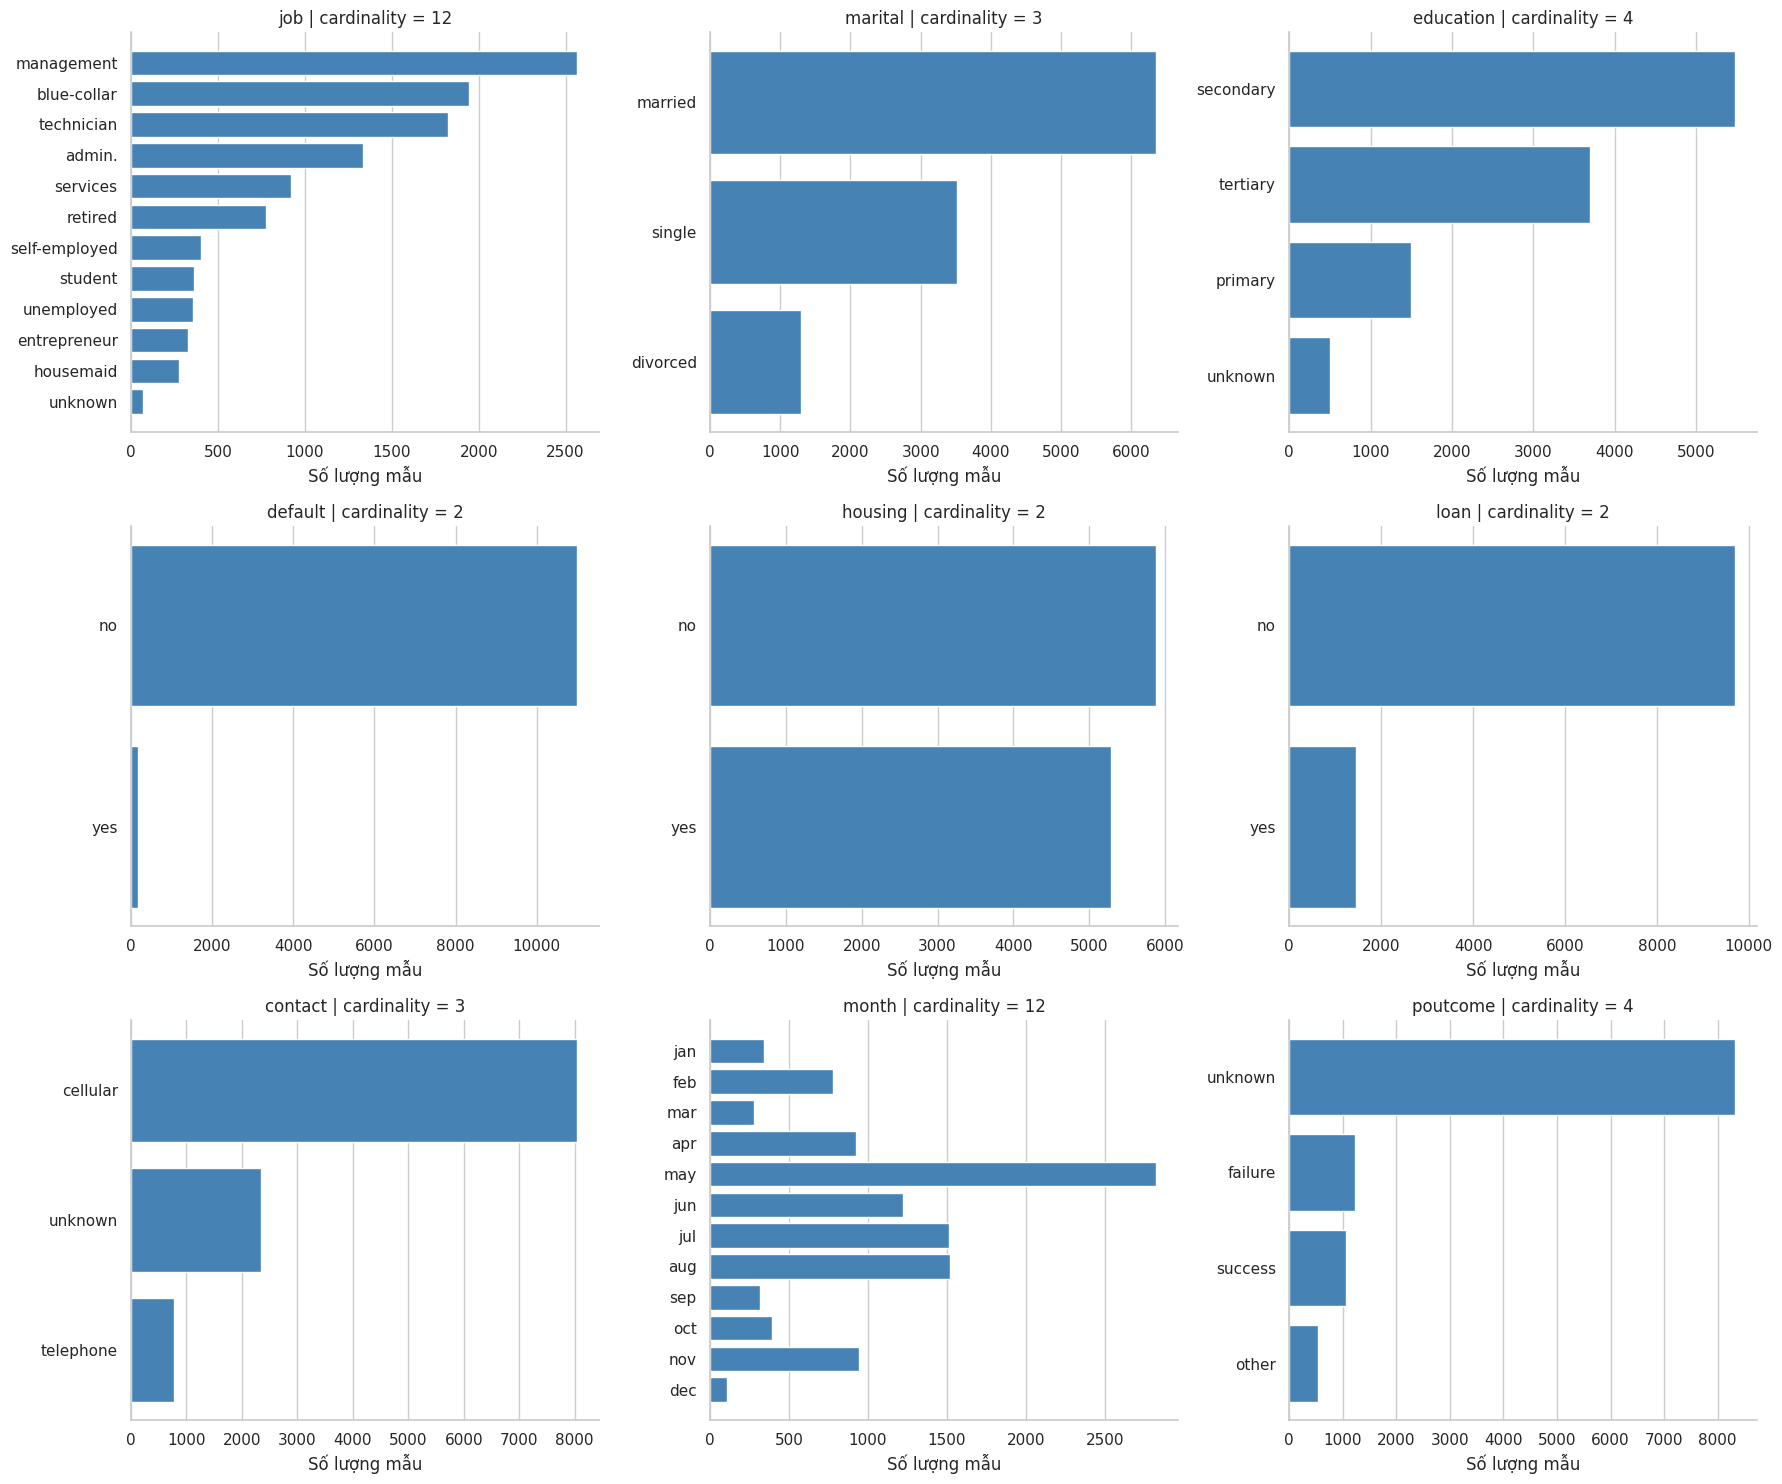

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

for ax, col in zip(axes.flatten(), categorical_cols):
    counts = categorical_tables[col]["count"]

    if col == "month":
        counts = counts.reindex(month_order, fill_value=0)

    ax.barh(counts.index, counts.values, color="steelblue")
    ax.invert_yaxis()

    ax.set_title(f"{col} | cardinality = {cardinality[col]}")
    ax.set_xlabel("Số lượng mẫu")
    ax.set_ylabel("")
    ax.grid(axis="y", visible=False)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "05_categorical_distributions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Nhận xét phân bố các đặc trưng phân loại

- Cardinality dao động từ 2 đến 12. `job` và `month` có 12 nhãn;
  `default`, `housing`, `loan` có 2 nhãn.
- `job` phổ biến nhất là `management` với 2.566 mẫu (22,99%).
- `marital` chủ yếu là `married` với 6.351 mẫu (56,90%).
- `education` phổ biến nhất là `secondary` với 5.476 mẫu (49,06%).
- `default` tập trung mạnh ở `no` (98,49%); `yes` chỉ chiếm 1,51%.
- `loan` chủ yếu là `no` (86,92%), trong khi `housing` tương đối cân bằng:
  `no` chiếm 52,69% và `yes` chiếm 47,31%.
- `contact` chủ yếu là `cellular` (72,05%), nhưng `unknown`
  vẫn chiếm 21,02%.
- `month` xuất hiện nhiều nhất là `may` (25,30%).
- `poutcome` có tỷ lệ `unknown` cao, khoảng 74,59%.
  Ngoài ra, `education` và `job` cũng có nhãn `unknown`,
  lần lượt khoảng 4,45% và 0,63%.

Sự chênh lệch giữa các nhãn của đặc trưng đầu vào không phải
mất cân bằng của biến mục tiêu `deposit`.

Các kết quả trên chỉ mô tả thành phần dữ liệu, chưa cho biết
nghề nghiệp, tháng liên hệ hoặc nhóm khách hàng nào có khả năng
đăng ký tiền gửi cao hơn.

## 2.2. Khám phá và trực quan hóa phân bố đơn biến

Phân tích đơn biến được thực hiện nhằm mô tả phân bố của biến mục tiêu và từng đặc trưng đầu vào trong bộ dữ liệu gồm 11.162 bản ghi. Các phương pháp sử dụng bao gồm thống kê tần suất, tỷ lệ phần trăm, thống kê mô tả, histogram kết hợp đường ước lượng mật độ KDE và biểu đồ thanh. Dữ liệu gốc được giữ nguyên trong quá trình khảo sát.

### 2.2.1. Phân bố biến mục tiêu

Biến mục tiêu `deposit` gồm hai lớp: `no` — khách hàng không đăng ký tiền gửi có kỳ hạn và `yes` — khách hàng đăng ký tiền gửi có kỳ hạn.

| Nhãn     | Số lượng mẫu |       Tỷ lệ |
| -------- | -----------: | ----------: |
| `no`     |        5.873 |      52,62% |
| `yes`    |        5.289 |      47,38% |
| **Tổng** |   **11.162** | **100,00%** |

Hai lớp chênh lệch 584 mẫu, tương ứng khoảng 5,23 điểm phần trăm tính từ tỷ lệ chưa làm tròn. Tỷ số giữa lớp đông và lớp ít khoảng 1,110:1. Như vậy, biến mục tiêu tương đối cân bằng, không xuất hiện mất cân bằng nhãn nghiêm trọng trong tập dữ liệu đang khảo sát.

Tỷ lệ trên phản ánh thành phần của bộ dữ liệu được cung cấp, chưa thể suy rộng thành tỷ lệ đăng ký tiền gửi của toàn bộ khách hàng ngân hàng.

*Chèn hình `02_target_distribution.png` — Phân bố biến mục tiêu `deposit`.*

### 2.2.2. Phân bố các đặc trưng số

Bảy đặc trưng số được khảo sát gồm `age`, `balance`, `day`, `duration`, `campaign`, `pdays` và `previous`. Bảng dưới trình bày một số chỉ số thống kê chính.

| Đặc trưng                 | Số mẫu sử dụng | Trung bình | Trung vị | Skewness |
| ------------------------- | -------------: | ---------: | -------: | -------: |
| `age`                     |         11.162 |     41,232 |       39 |    0,863 |
| `balance`                 |         11.162 |  1.528,539 |      550 |    8,225 |
| `day`                     |         11.162 |     15,658 |       15 |    0,111 |
| `duration`                |         11.162 |    371,994 |      255 |    2,144 |
| `campaign`                |         11.162 |      2,508 |        2 |    5,546 |
| `pdays` — chỉ giá trị ≥ 0 |          2.838 |    204,818 |      182 |    1,275 |
| `previous`                |         11.162 |      0,833 |        0 |    7,335 |

**Độ tuổi (`age`).** Tuổi khách hàng nằm trong khoảng 18–95 tuổi, có trung vị 39 tuổi và trung bình 41,232 tuổi. Phân vị thứ nhất và thứ ba lần lượt là 32 và 49 tuổi. Skewness bằng 0,863 cho thấy phân bố lệch phải vừa, với đuôi kéo dài về phía các độ tuổi cao.

**Số dư tài khoản (`balance`).** Phân bố lệch phải rất mạnh, với skewness 8,225. Trung bình 1.528,539 Euro cao hơn đáng kể trung vị 550 Euro; Q1 và Q3 lần lượt là 122 và 1.708 Euro. Giá trị lớn nhất đạt 81.204 Euro, cho thấy một số số dư lớn nằm xa phần trung tâm của dữ liệu. Cột này cũng có giá trị âm, nhỏ nhất −6.847 Euro. Các giá trị âm và cực đoan được giữ lại khi khảo sát, không tự động coi là lỗi dữ liệu chỉ dựa vào dấu hoặc độ lớn.

**Ngày liên hệ (`day`).** Giá trị nằm trong khoảng 1–31, có trung vị 15 và skewness 0,111. Chỉ số này cho thấy mức bất đối xứng thấp, nhưng không đủ để kết luận phân bố chuẩn. Do `day` là biến số nguyên rời rạc, histogram sử dụng các khoảng có biên khớp với từng ngày để phản ánh đúng tần suất.

**Thời lượng cuộc gọi (`duration`).** Trung vị là 255 giây, trong khi trung bình khoảng 371,994 giây. Giá trị lớn nhất đạt 3.881 giây và skewness bằng 2,144. Kết quả cho thấy phân bố lệch phải mạnh, với một số cuộc gọi dài kéo trung bình lên.

**Số lần liên hệ (`campaign`, `previous`).** Cả hai biến đều lệch phải mạnh, với skewness lần lượt là 5,546 và 7,335. `campaign` có trung vị 2 lần, Q3 bằng 3 lần và cực đại 63 lần. `previous` có trung vị 0, Q3 bằng 1 lần và cực đại 58 lần. Như vậy, các quan sát tập trung ở số lần liên hệ thấp, trong khi một số bản ghi có số lần liên hệ cao tạo thành đuôi phải dài.

**Số ngày kể từ lần liên hệ trước (`pdays`).** Giá trị −1 là mã biểu thị chưa từng được liên hệ trước đó, không phải khoảng thời gian thực. Có 8.324 bản ghi (74,57%) mang mã này và 2.838 bản ghi (25,43%) có số ngày hợp lệ. Vì vậy, nhóm thống kê riêng trạng thái liên hệ và chỉ sử dụng các giá trị `pdays ≥ 0` để tính thống kê thời gian và vẽ histogram.

Trong nhóm có số ngày hợp lệ, trung bình là 204,818 ngày, trung vị 182 ngày, Q1 bằng 98 ngày và Q3 bằng 286 ngày. Giá trị nhỏ nhất là 1 ngày, lớn nhất là 854 ngày; skewness 1,275 cho thấy phân bố lệch phải. Các chỉ số này chỉ mô tả nhóm đã từng được liên hệ. Số mẫu 2.838 trong bảng là số bản ghi dùng để phân tích thời gian, không có nghĩa dữ liệu gốc bị thiếu 8.324 giá trị.

Nhìn chung, phần lớn các đặc trưng số có phân bố lệch phải. `day` có độ bất đối xứng thấp, nhưng chưa có cơ sở khẳng định đặc trưng nào tuân theo phân bố chuẩn chỉ từ histogram, KDE và skewness. Đường KDE được sử dụng để hỗ trợ quan sát hình dạng, cần diễn giải thận trọng đối với các biến rời rạc.

*Chèn hình `04_feature_histograms.png` — Histogram và KDE của các đặc trưng số; riêng `pdays` chỉ sử dụng nhóm đã từng được liên hệ.*

### 2.2.3. Phân bố các đặc trưng phân loại

Chín đặc trưng phân loại được khảo sát bằng số lượng nhãn khác nhau (cardinality), bảng tần suất và biểu đồ thanh. Các nhãn `unknown` được giữ nguyên để thể hiện đầy đủ thành phần dữ liệu.

| Đặc trưng   | Cardinality | Nhãn phổ biến nhất | Số mẫu |  Tỷ lệ |
| ----------- | ----------: | ------------------ | -----: | -----: |
| `job`       |          12 | `management`       |  2.566 | 22,99% |
| `marital`   |           3 | `married`          |  6.351 | 56,90% |
| `education` |           4 | `secondary`        |  5.476 | 49,06% |
| `default`   |           2 | `no`               | 10.994 | 98,49% |
| `housing`   |           2 | `no`               |  5.881 | 52,69% |
| `loan`      |           2 | `no`               |  9.702 | 86,92% |
| `contact`   |           3 | `cellular`         |  8.042 | 72,05% |
| `month`     |          12 | `may`              |  2.824 | 25,30% |
| `poutcome`  |           4 | `unknown`          |  8.326 | 74,59% |

Cardinality dao động từ 2 đến 12. `job` và `month` có nhiều nhãn nhất, trong khi `default`, `housing` và `loan` là các biến hai nhãn. Nghề nghiệp xuất hiện nhiều nhất là `management`, nhưng chỉ chiếm 22,99%, cho thấy dữ liệu phân bố trên nhiều nhóm nghề. `marital` chủ yếu là `married` (56,90%), còn `education` phổ biến nhất là `secondary` (49,06%).

Phân bố của `default` tập trung mạnh ở nhãn `no` (98,49%), trong khi `yes` chỉ có 168 mẫu (1,51%). `loan` cũng thiên về `no` (86,92%). Ngược lại, `housing` tương đối cân bằng, với `no` chiếm 52,69% và `yes` chiếm 47,31%. Sự chênh lệch trong các đặc trưng đầu vào này cần được phân biệt với mất cân bằng nhãn của biến mục tiêu `deposit`.

Đối với thông tin liên hệ, `cellular` chiếm 72,05% ở cột `contact`, còn `unknown` chiếm 21,02%. Tháng xuất hiện nhiều nhất là `may` (25,30%). Những tỷ lệ này phản ánh mức xuất hiện trong tập dữ liệu, chưa đủ để kết luận phương thức hoặc tháng liên hệ nào mang lại hiệu quả tiếp thị cao hơn.

Đáng chú ý, `poutcome` có 74,59% nhãn `unknown`, cho thấy phần lớn bản ghi không có kết quả chiến dịch trước được xác định trong cột này. `education` và `job` cũng có nhãn `unknown`, lần lượt chiếm 4,45% và 0,63%. Các nhãn này được giữ rõ trong phân tích để lưu ý khi lựa chọn cách tiền xử lý ở giai đoạn tiếp theo.

*Chèn hình `05_categorical_distributions.png` — Phân bố tần suất của các đặc trưng phân loại.*


# PHẦN C — PHẦN PHÂN TÍCH CỦA NHÂN

# BÀI TẬP LỚN MACHINE LEARNING
## Notebook 03: Phân tích Tương quan & Quan hệ Đa biến

**Người thực hiện:** Nhân / Person 4  
**Mục tiêu:** Phân tích quan hệ giữa các biến số, sàng lọc đa cộng tuyến, so sánh đặc trưng theo biến mục tiêu `deposit` và kiểm tra nguy cơ rò rỉ dữ liệu.

> Lưu ý: tương quan chỉ mô tả mối liên hệ trong tập dữ liệu, không chứng minh quan hệ nhân quả.


### 1. Khởi tạo, đọc dữ liệu và xác định biến phân tích
Chỉ các đại lượng số có ý nghĩa mới được dùng cho Pearson/Spearman. Các biến phân loại danh nghĩa không được gán mã số tùy ý để diễn giải tương quan. Riêng `pdays = -1` là mã “chưa từng liên hệ”, nên bị tách khỏi phần số ngày thực.


**Điều chỉnh tích hợp bắt buộc:** `df` đã được đọc ở Phần A, nên cell dưới chỉ bổ sung thư viện/phép kiểm tra cần cho phân tích của Nhân; không tải lại dataset.

In [16]:
from itertools import combinations
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.linear_model import LinearRegression

target_col = 'deposit'
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
expected_cols = [
    'age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
    'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
    'previous', 'poutcome', target_col
]
assert df.columns.tolist() == expected_cols, 'Schema không khớp với bank.csv.'
assert set(df[target_col].unique()) == {'no', 'yes'}, 'Nhãn deposit không hợp lệ.'

target_binary = df[target_col].map({'no': 0, 'yes': 1})
relationship_data = df[numeric_cols].copy()
relationship_data['pdays'] = relationship_data['pdays'].where(relationship_data['pdays'] >= 0)
relationship_data = relationship_data.rename(columns={'pdays': 'pdays (>= 0)'})

print(f'Kích thước dữ liệu: {df.shape[0]:,} dòng × {df.shape[1]} cột')
print(f'Số bản ghi đã từng liên hệ dùng cho pdays: {relationship_data["pdays (>= 0)"].notna().sum():,}')

Kích thước dữ liệu: 11,162 dòng × 17 cột
Số bản ghi đã từng liên hệ dùng cho pdays: 2,838


### 2. Ma trận tương quan Pearson và Spearman
Pearson được dùng để mô tả quan hệ tuyến tính; Spearman dùng thứ hạng nên ít nhạy hơn với phân bố lệch và ngoại lai. Các ô liên quan `pdays (>= 0)` được tính theo cặp trên 2.838 khách hàng đã từng được liên hệ.


Ma trận Pearson:


,age,balance,day,duration,campaign,pdays (>= 0),previous
age,1.000,0.112,-0.001,0.000,-0.005,-0.063,0.020
balance,0.112,1.000,0.010,0.022,-0.014,-0.063,0.031
day,-0.001,0.010,1.000,-0.019,0.137,-0.032,-0.059
duration,0.000,0.022,-0.019,1.000,-0.042,0.038,-0.027
campaign,-0.005,-0.014,0.137,-0.042,1.000,0.040,-0.050
pdays (>= 0),-0.063,-0.063,-0.032,0.038,0.040,1.000,-0.012
previous,0.020,0.031,-0.059,-0.027,-0.050,-0.012,1.000


Ma trận Spearman:


,age,balance,day,duration,campaign,pdays (>= 0),previous
age,1.000,0.106,-0.001,-0.014,0.019,-0.023,0.012
balance,0.106,1.000,0.000,0.058,-0.039,-0.114,0.097
day,-0.001,0.000,1.000,-0.044,0.110,-0.021,-0.085
duration,-0.014,0.058,-0.044,1.000,-0.054,0.022,0.018
campaign,0.019,-0.039,0.110,-0.054,1.000,0.074,-0.118
pdays (>= 0),-0.023,-0.114,-0.021,0.022,0.074,1.000,-0.121
previous,0.012,0.097,-0.085,0.018,-0.118,-0.121,1.000


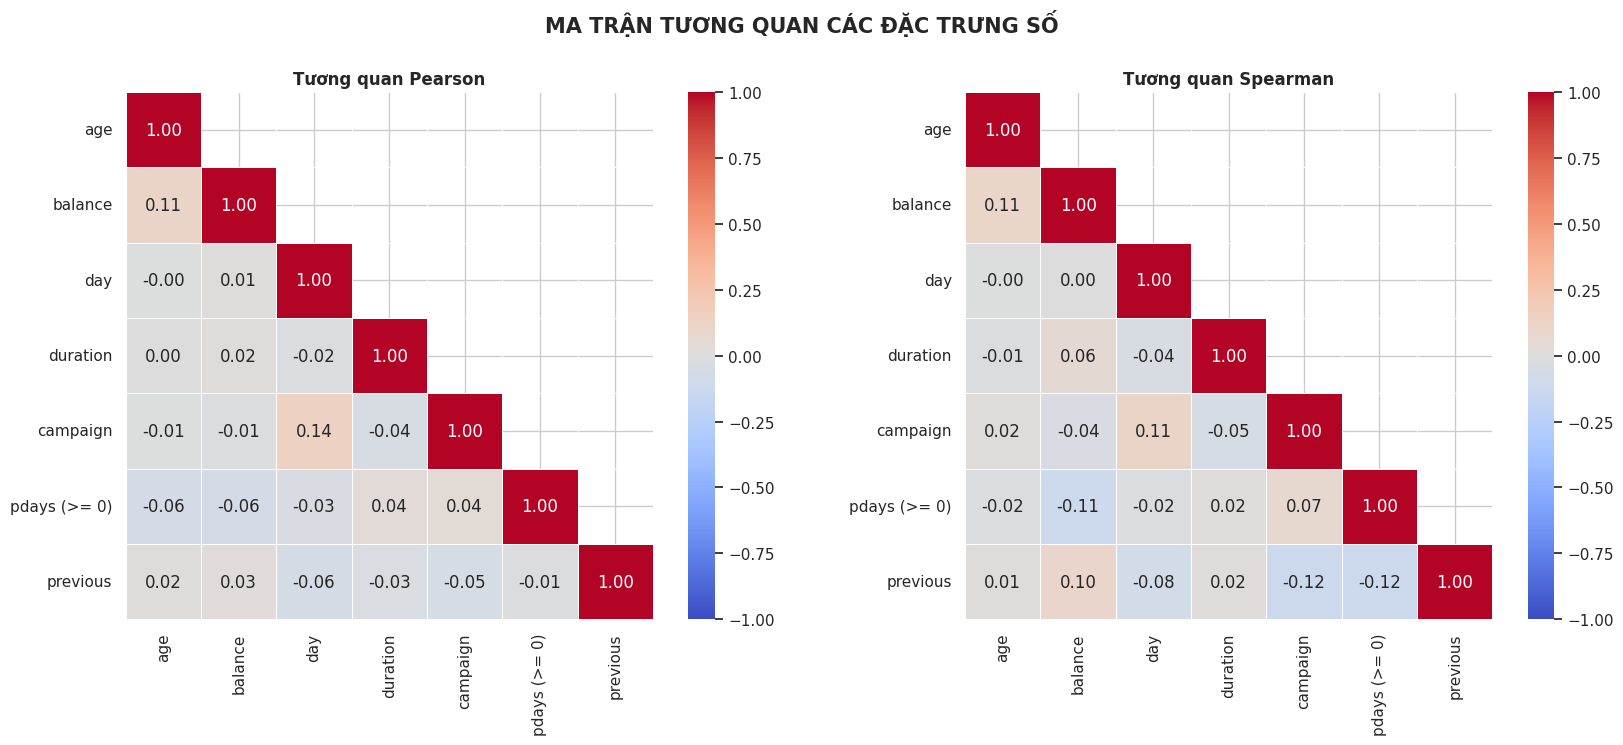

Đã lưu tại: E:\Downloads\BTL_ML_git\figures\03_correlation_matrix.png


In [17]:
pearson_corr = relationship_data.corr(method='pearson')
spearman_corr = relationship_data.corr(method='spearman')

print('Ma trận Pearson:')
display(pearson_corr.round(3))
print('Ma trận Spearman:')
display(spearman_corr.round(3))

mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, matrix, title in [
    (axes[0], pearson_corr, 'Tương quan Pearson'),
    (axes[1], spearman_corr, 'Tương quan Spearman'),
]:
    sns.heatmap(
        matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
        vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax
    )
    ax.set_title(title, fontweight='bold')

plt.suptitle('MA TRẬN TƯƠNG QUAN CÁC ĐẶC TRƯNG SỐ', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
correlation_path = FIGURE_DIR / '03_correlation_matrix.png'
plt.savefig(correlation_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Đã lưu tại: {correlation_path}')


### Nhận xét tương quan giữa các đặc trưng số

- Không có cặp đặc trưng số nào tương quan mạnh. Pearson lớn nhất theo trị tuyệt đối là `day` – `campaign` (khoảng 0,137); Spearman lớn nhất khoảng 0,121 giữa `previous` và `pdays` trong nhóm đã từng liên hệ.
- `age` và `balance` có tương quan dương yếu (Pearson khoảng 0,112).
- Dấu và độ lớn giữa Pearson/Spearman có khác nhẹ do `balance`, `campaign`, `previous` và `pdays` có phân bố lệch.
- Các kết quả chỉ cho biết quan hệ thống kê; không được diễn giải thành nguyên nhân.


### 3. Sàng lọc cặp tương quan mạnh và đa cộng tuyến
Ngưỡng `|r| >= 0,8` và `VIF > 5` dưới đây chỉ là **heuristic sàng lọc**, không phải ngưỡng khoa học phổ quát. `pdays` không được đưa vào VIF toàn bộ dữ liệu vì `-1` là sentinel; biến này đã được xem riêng trong ma trận tương quan.


In [18]:
correlation_threshold = 0.8
strong_rows = []
for method, matrix in [('Pearson', pearson_corr), ('Spearman', spearman_corr)]:
    for left, right in combinations(matrix.columns, 2):
        value = matrix.loc[left, right]
        if abs(value) >= correlation_threshold:
            strong_rows.append({
                'Phương pháp': method, 'Biến 1': left, 'Biến 2': right,
                'Hệ số': value, 'Heuristic': '|r| >= 0.8'
            })
strong_pairs = pd.DataFrame(strong_rows)
if strong_pairs.empty:
    print('Không có cặp đặc trưng nào vượt heuristic |r| >= 0.8.')
else:
    display(strong_pairs.round(3))

vif_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'previous']
vif_rows = []
for col in vif_cols:
    predictors = df[vif_cols].drop(columns=col)
    r_squared = LinearRegression().fit(predictors, df[col]).score(predictors, df[col])
    vif_rows.append({
        'Đặc trưng': col, 'R² từ các biến còn lại': r_squared,
        'VIF': 1 / (1 - r_squared), 'VIF > 5': 1 / (1 - r_squared) > 5
    })
vif_table = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)
display(vif_table.round(3))


Không có cặp đặc trưng nào vượt heuristic |r| >= 0.8.


,Đặc trưng,R² từ các biến còn lại,VIF,VIF > 5
4,campaign,0.022,1.023,False
2,day,0.022,1.022,False
1,balance,0.014,1.014,False
0,age,0.013,1.013,False
5,previous,0.007,1.007,False
3,duration,0.003,1.003,False


Kết quả VIF chỉ dao động khoảng 1,00–1,02. Vì vậy, chưa có dấu hiệu đa cộng tuyến đáng kể giữa các đặc trưng số được sàng lọc.


### 4. Quan hệ giữa đặc trưng số và biến mục tiêu
Vì `deposit` có hai lớp, point-biserial correlation được dùng cho biến số. Bảng đồng thời trình bày trung bình, trung vị theo lớp và standardized mean difference (SMD) để tránh chỉ dựa vào p-value.


,Đặc trưng,Số mẫu,Point-biserial r,p-value,Mean (no),Mean (yes),Median (no),Median (yes),SMD
3,duration,11162,0.452,0.0,223.130,537.295,163.0,426.0,1.015
6,pdays (>= 0),2838,-0.144,0.0,229.925,192.522,208.0,181.0,-0.309
5,previous,11162,0.140,0.0,0.528,1.170,0.0,0.0,0.283
4,campaign,11162,-0.128,0.0,2.839,2.141,2.0,2.0,-0.259
1,balance,11162,0.081,0.0,1280.227,1804.268,414.0,733.0,0.163
2,day,11162,-0.056,0.0,16.108,15.158,16.0,15.0,-0.113
0,age,11162,0.035,0.0,40.837,41.670,39.0,38.0,0.070


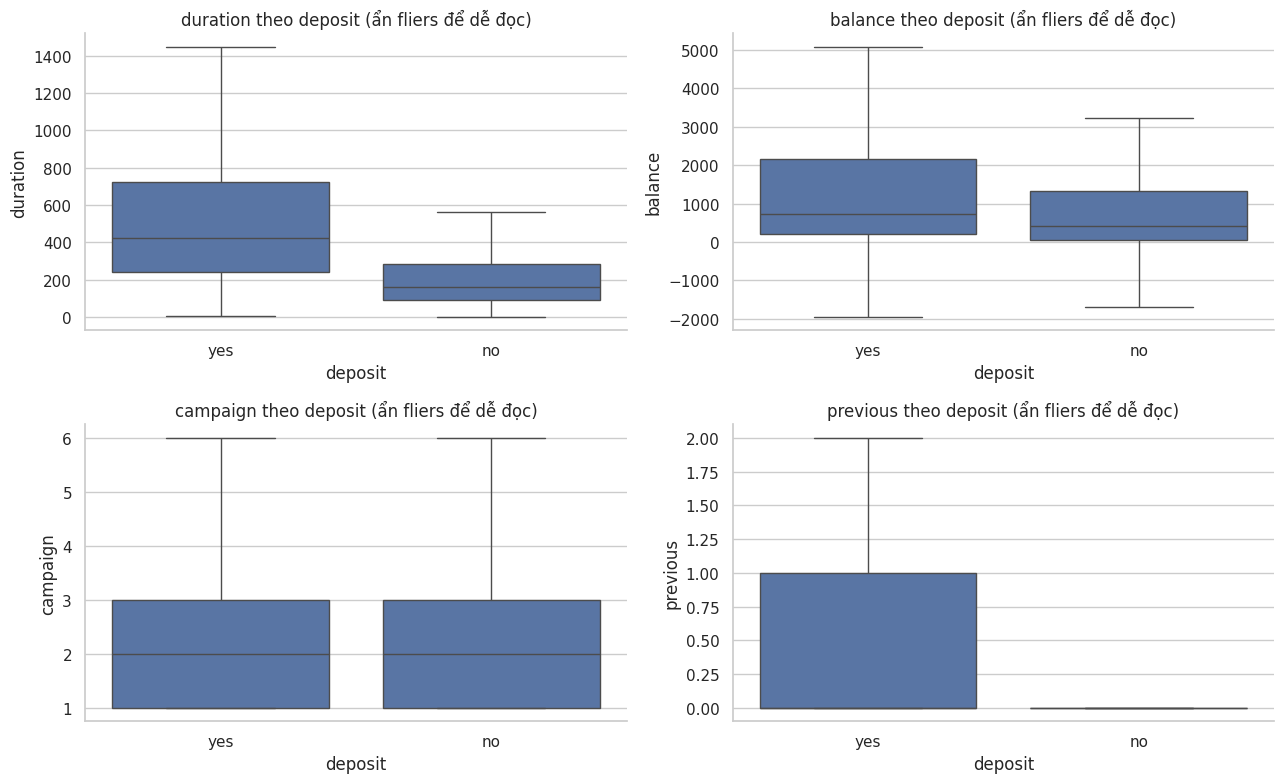

In [19]:
target_rows = []
for col in ['age', 'balance', 'day', 'duration', 'campaign', 'previous']:
    values_no = df.loc[df[target_col] == 'no', col]
    values_yes = df.loc[df[target_col] == 'yes', col]
    r_value, p_value = pointbiserialr(target_binary, df[col])
    pooled_sd = np.sqrt(
        ((len(values_no) - 1) * values_no.var() + (len(values_yes) - 1) * values_yes.var())
        / (len(values_no) + len(values_yes) - 2)
    )
    target_rows.append({
        'Đặc trưng': col, 'Số mẫu': len(df), 'Point-biserial r': r_value,
        'p-value': p_value, 'Mean (no)': values_no.mean(), 'Mean (yes)': values_yes.mean(),
        'Median (no)': values_no.median(), 'Median (yes)': values_yes.median(),
        'SMD': (values_yes.mean() - values_no.mean()) / pooled_sd
    })

contacted = df['pdays'] >= 0
values_no = df.loc[contacted & df[target_col].eq('no'), 'pdays']
values_yes = df.loc[contacted & df[target_col].eq('yes'), 'pdays']
r_value, p_value = pointbiserialr(target_binary[contacted], df.loc[contacted, 'pdays'])
pooled_sd = np.sqrt(
    ((len(values_no) - 1) * values_no.var() + (len(values_yes) - 1) * values_yes.var())
    / (len(values_no) + len(values_yes) - 2)
)
target_rows.append({
    'Đặc trưng': 'pdays (>= 0)', 'Số mẫu': int(contacted.sum()),
    'Point-biserial r': r_value, 'p-value': p_value,
    'Mean (no)': values_no.mean(), 'Mean (yes)': values_yes.mean(),
    'Median (no)': values_no.median(), 'Median (yes)': values_yes.median(),
    'SMD': (values_yes.mean() - values_no.mean()) / pooled_sd
})

target_relationships = (
    pd.DataFrame(target_rows)
    .assign(abs_r=lambda table: table['Point-biserial r'].abs())
    .sort_values('abs_r', ascending=False)
    .drop(columns='abs_r')
)
display(target_relationships.round(3))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flatten(), ['duration', 'balance', 'campaign', 'previous']):
    sns.boxplot(data=df, x=target_col, y=col, showfliers=False, ax=ax)
    ax.set_title(f'{col} theo deposit (ẩn fliers để dễ đọc)')
plt.tight_layout()
plt.show()


### Nhận xét quan hệ đặc trưng – mục tiêu

- `duration` nổi bật nhất: point-biserial `r ≈ 0,452`, trung bình 223 giây ở lớp `no` và 537 giây ở lớp `yes`, SMD khoảng 1,015. Đây là liên hệ mạnh về mặt mô tả nhưng cũng là biến cần kiểm tra leakage theo thời điểm dự đoán.
- Trong nhóm đã từng liên hệ, `pdays` có liên hệ âm yếu-vừa (`r ≈ -0,144`): nhóm `yes` có trung bình khoảng 193 ngày, thấp hơn nhóm `no` khoảng 230 ngày.
- `previous` liên hệ dương (`r ≈ 0,140`), còn `campaign` liên hệ âm (`r ≈ -0,128`).
- `balance`, `day`, `age` có quan hệ biên yếu hơn. Các kết quả không chứng minh rằng thay đổi các biến này sẽ gây ra đăng ký tiền gửi.


### 5. Quan hệ của biến phân loại với mục tiêu
Các biến danh nghĩa được đánh giá bằng Cramér's V và tỷ lệ `deposit = yes`, không dùng Pearson trên mã category.


In [20]:
def cramers_v(feature, target):
    contingency = pd.crosstab(feature, target)
    chi2 = chi2_contingency(contingency, correction=False)[0]
    n = contingency.to_numpy().sum()
    denominator = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
    return np.sqrt((chi2 / n) / denominator)

categorical_cols = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'poutcome'
]
categorical_rows = []
for col in categorical_cols:
    yes_rates = df.groupby(col, observed=True)[target_col].apply(lambda values: values.eq('yes').mean())
    categorical_rows.append({
        'Đặc trưng': col, 'Cramér V': cramers_v(df[col], df[target_col]),
        'Nhóm có tỷ lệ yes thấp nhất': yes_rates.idxmin(),
        'Tỷ lệ yes thấp nhất': yes_rates.min(),
        'Nhóm có tỷ lệ yes cao nhất': yes_rates.idxmax(),
        'Tỷ lệ yes cao nhất': yes_rates.max(),
    })
categorical_relationships = (
    pd.DataFrame(categorical_rows)
    .sort_values('Cramér V', ascending=False)
)
display(categorical_relationships.round(3))

previously_contacted_rates = pd.crosstab(contacted, df[target_col], normalize='index')
previously_contacted_rates.index = ['Chưa từng liên hệ', 'Đã từng liên hệ']
display(previously_contacted_rates.round(3))


,Đặc trưng,Cramér V,Nhóm có tỷ lệ yes thấp nhất,Tỷ lệ yes thấp nhất,Nhóm có tỷ lệ yes cao nhất,Tỷ lệ yes cao nhất
7,month,0.306,may,0.328,dec,0.909
8,poutcome,0.300,unknown,0.407,success,0.913
6,contact,0.257,unknown,0.226,cellular,0.543
4,housing,0.204,yes,0.366,no,0.570
0,job,0.184,blue-collar,0.364,student,0.747
5,loan,0.111,yes,0.332,no,0.495
2,education,0.105,primary,0.394,tertiary,0.541
1,marital,0.099,married,0.434,single,0.543
3,default,0.041,yes,0.310,no,0.476


deposit,no,yes
Chưa từng liên hệ,0.593,0.407
Đã từng liên hệ,0.329,0.671


`month` (`V ≈ 0,306`), `poutcome` (`V ≈ 0,300`) và `contact` (`V ≈ 0,257`) có mức liên hệ lớn nhất trong nhóm biến phân loại. Đặc biệt, `poutcome = success` có tỷ lệ `yes` khoảng 91,3%, còn khách hàng đã từng được liên hệ có tỷ lệ `yes` khoảng 67,1%. Đây là các dấu hiệu cần kiểm tra về thời điểm và nguồn tạo dữ liệu, không phải bằng chứng nhân quả.


### 6. Kiểm tra rò rỉ dữ liệu và biến đáng ngờ


In [21]:
direct_target_copies = [
    col for col in df.columns if col != target_col
    and df[col].astype(str).equals(df[target_col].astype(str))
]
poutcome_success_rate = df.loc[df['poutcome'].eq('success'), target_col].eq('yes').mean()
leakage_audit = pd.DataFrame([
    {
        'Kiểm tra': 'Cột định danh',
        'Kết quả': 'Không có cột ID rõ ràng',
        'Đánh giá': 'Giảm nguy cơ ghi nhớ ID, nhưng không thể group theo khách hàng để kiểm tra lặp thực thể.'
    },
    {
        'Kiểm tra': 'Bản ghi trùng hoàn toàn / trùng predictor',
        'Kết quả': f'{df.duplicated().sum()} / {df.drop(columns=target_col).duplicated().sum()}',
        'Đánh giá': 'Không phát hiện duplicate hoặc cặp predictor giống nhau mang nhãn khác.'
    },
    {
        'Kiểm tra': 'Cột sao chép trực tiếp target',
        'Kết quả': str(direct_target_copies),
        'Đánh giá': 'Không phát hiện cột nào trùng hoàn toàn với deposit.'
    },
    {
        'Kiểm tra': 'duration',
        'Kết quả': f'r = {target_relationships.set_index("Đặc trưng").loc["duration", "Point-biserial r"]:.3f}',
        'Đánh giá': 'Chỉ biết sau/khi cuộc gọi diễn ra; là leakage nếu mục tiêu là dự đoán trước cuộc gọi.'
    },
    {
        'Kiểm tra': 'poutcome = success',
        'Kết quả': f'Tỷ lệ yes = {poutcome_success_rate:.3%}',
        'Đánh giá': 'Kết quả chiến dịch trước, không phải nhãn hiện tại; vẫn phải xác nhận được ghi nhận trước dự đoán.'
    },
    {
        'Kiểm tra': 'pdays sentinel và previous',
        'Kết quả': f'{df["pdays"].eq(-1).sum():,} dòng pdays=-1; {df["previous"].eq(0).sum():,} dòng previous=0',
        'Đánh giá': 'Hai biến cùng mã hóa lịch sử chưa liên hệ; cần tránh diễn giải -1 như khoảng cách số.'
    },
])
display(leakage_audit)


,Kiểm tra,Kết quả,Đánh giá
0,Cột định danh,Không có cột ID rõ ràng,"Giảm nguy cơ ghi nhớ ID, nhưng không thể group..."
1,Bản ghi trùng hoàn toàn / trùng predictor,0 / 0,Không phát hiện duplicate hoặc cặp predictor g...
2,Cột sao chép trực tiếp target,[],Không phát hiện cột nào trùng hoàn toàn với de...
3,duration,r = 0.452,Chỉ biết sau/khi cuộc gọi diễn ra; là leakage ...
4,poutcome = success,Tỷ lệ yes = 91.317%,"Kết quả chiến dịch trước, không phải nhãn hiện..."
5,pdays sentinel và previous,"8,324 dòng pdays=-1; 8,324 dòng previous=0",Hai biến cùng mã hóa lịch sử chưa liên hệ; cần...


## 2.3. Phân tích tương quan và quan hệ đa biến

Phân tích Pearson và Spearman được thực hiện trên bảy biến số, trong đó `pdays = -1` được xem là mã sentinel và loại khỏi phép tính số ngày. Không có cặp đặc trưng nào vượt heuristic sàng lọc `|r| >= 0,8`; hệ số lớn nhất chỉ khoảng 0,137 theo Pearson. VIF của các biến số dùng trên toàn bộ dữ liệu nằm trong khoảng 1,00–1,02, do đó chưa có dấu hiệu đa cộng tuyến đáng kể.

Đối với biến mục tiêu, `duration` có quan hệ nổi bật nhất (`r ≈ 0,452`, SMD ≈ 1,015), tiếp theo là `pdays` trong nhóm đã từng liên hệ (`r ≈ -0,144`), `previous` (`r ≈ 0,140`) và `campaign` (`r ≈ -0,128`). Trong nhóm biến phân loại, `month`, `poutcome` và `contact` có Cramér's V lần lượt khoảng 0,306; 0,300 và 0,257. Những hệ số này chỉ phản ánh association trong mẫu, không cho phép kết luận nhân quả.

Kiểm tra leakage không phát hiện cột ID, bản ghi trùng predictor hoặc cột sao chép trực tiếp `deposit`. Tuy nhiên, `duration` chỉ được biết trong/sau cuộc gọi nên sẽ gây rò rỉ nếu bài toán yêu cầu dự đoán trước khi liên hệ. `poutcome = success` có tỷ lệ đăng ký khoảng 91,3% nhưng là kết quả của chiến dịch trước; biến này chỉ hợp lệ khi chắc chắn có sẵn trước thời điểm dự đoán hiện tại.


### Kết luận

- Không phát hiện cặp số tương quan mạnh hoặc đa cộng tuyến đáng kể.
- `duration` là biến liên hệ với mục tiêu mạnh nhất nhưng đồng thời là rủi ro leakage phụ thuộc thời điểm dự đoán.
- `poutcome`, trạng thái đã liên hệ trước, `month` và `contact` cần được giữ đúng ngữ nghĩa nghiệp vụ khi đánh giá mô hình.
- Không mã hóa category danh nghĩa thành ID số để diễn giải Pearson, và không có kết luận nhân quả nào được đưa ra.


## 2.4. Các thách thức dữ liệu cốt lõi

Danh sách dưới đây được tổng hợp từ kết quả thực tế của ba notebook Week 1; các điểm chỉ là vấn đề cần xử lý/kiểm chứng, không phải kết luận nhân quả.

1. Không có `NaN` tường minh, nhưng bốn biến phân loại vẫn chứa nhãn `unknown`; kiểm tra `isna()` đơn thuần sẽ bỏ sót.
2. `poutcome` có 8.326 giá trị `unknown` (74,59%), mức thiếu ngầm định rất lớn.
3. `contact` có 2.346 giá trị `unknown` (21,02%).
4. `education` có 497 giá trị `unknown` (4,45%).
5. `job` có 70 giá trị `unknown` (0,63%).
6. Với `poutcome`, `unknown` có thể đồng thời phản ánh chưa có chiến dịch trước và không biết kết quả; cần giữ đúng ngữ nghĩa.
7. `pdays = -1` xuất hiện 8.324 dòng (74,57%) và là sentinel, không phải số ngày âm.
8. Chỉ 2.838 dòng có `pdays >= 0`; mọi thống kê số ngày liên hệ trước dựa trên tập con nhỏ hơn.
9. Có 2 dòng `pdays >= 0` nhưng `poutcome = unknown`, cần giữ như một bất nhất nhỏ cần kiểm tra nguồn.
10. Dataset không có mã khách hàng/ID rõ ràng, nên không thể xác minh một khách hàng có xuất hiện nhiều lần hay không.
11. Không có duplicate hoàn toàn hoặc duplicate predictor, nhưng thiếu ID vẫn ngăn grouped split theo khách hàng.
12. Target hơi lệch: 5.873 `no` (52,62%) và 5.289 `yes` (47,38%); cần giữ tỷ lệ khi chia dữ liệu.
13. `default = yes` chỉ có 168 dòng (1,51%), làm ước lượng cho nhóm này kém ổn định hơn.
14. `loan = yes` chỉ chiếm 13,08%, tạo chênh lệch tần suất giữa hai mức.
15. `contact = telephone` chỉ có 774 dòng (6,93%), nhỏ hơn nhiều so với `cellular`.
16. Tần suất theo tháng rất lệch: `may` có 2.824 dòng trong khi `dec` chỉ có 110 dòng.
17. Các biến danh nghĩa như `job`, `month`, `contact` không được mã số tùy ý rồi diễn giải Pearson.
18. `balance` có 688 giá trị âm (6,16%) nhưng đây có thể là thấu chi hợp lệ, không được tự động coi là lỗi.
19. `balance` lệch phải mạnh (skewness 8,225), tối đa 81.204 và có 1.055 điểm bị heuristic IQR gắn cờ.
20. `duration` lệch phải (skewness 2,144), tối đa 3.881 giây và có 636 điểm IQR.
21. `campaign` lệch phải mạnh (skewness 5,546), tối đa 63 lần và có 601 điểm IQR.
22. `previous` lệch phải mạnh (skewness 7,335), trung vị 0, tối đa 58 và có 1.258 điểm IQR.
23. `age` đạt tối đa 95 và có 171 điểm IQR; cần kiểm tra chứ không xóa cơ học.
24. Trong nhóm đã liên hệ, `pdays` đạt 854 ngày và có 32 điểm IQR.
25. Quy tắc 1,5×IQR chỉ là heuristic sàng lọc; điểm bị gắn cờ không đồng nghĩa dữ liệu sai.
26. `duration` liên hệ mạnh nhất với target (`r ≈ 0,452`, SMD ≈ 1,015) nhưng chưa biết trước cuộc gọi, nên có thể gây leakage.
27. `campaign` liên hệ âm với target (`r ≈ -0,128`); số lần liên hệ có thể phản ánh quy trình chiến dịch chứ không phải nguyên nhân.
28. `previous` có trung vị 0 ở cả hai lớp nhưng mean khác nhau và `r ≈ 0,140`, cho thấy phân bố zero-inflated.
29. Không có đa cộng tuyến mạnh (VIF khoảng 1), nhưng `pdays=-1` và `previous=0` cùng mã hóa trạng thái chưa liên hệ.
30. `day` và `month` là thành phần lịch; quan hệ mùa vụ không được mô tả tốt bằng một hệ số tuyến tính đơn giản.
31. Dataset không có năm, nên không thể dựng chronological split đầy đủ hoặc kiểm tra drift theo năm.
32. `month` có Cramér's V khoảng 0,306 và tỷ lệ `yes` từ 32,75% đến 90,91%; chênh lệch có thể bị ảnh hưởng bởi cỡ mẫu/thời điểm chiến dịch.
33. `poutcome = success` có tỷ lệ `yes` 91,32%; đây là biến gần target cần xác nhận chắc chắn thuộc chiến dịch trước.
34. `contact = unknown` có tỷ lệ `yes` 22,59% so với 54,33% ở `cellular`, có thể phản ánh missingness hoặc quy trình vận hành.
35. Nhóm đã từng liên hệ có tỷ lệ `yes` 67,12% so với 40,65% ở nhóm chưa liên hệ; cần kiểm tra selection/history bias và thời điểm sẵn có.

## Kết luận Data Phase

- Dữ liệu đúng gồm 11.162 dòng, 17 cột và target `deposit`; không có `NaN` hoặc duplicate hoàn toàn.
- Chất lượng dữ liệu chủ yếu bị chi phối bởi nhãn `unknown`, sentinel `pdays=-1`, phân bố lệch và ngoại lai.
- Phân bố target tương đối cân bằng; các phân tích của Trí và Danh được kế thừa trực tiếp.
- Không có cặp số tương quan mạnh hoặc đa cộng tuyến đáng kể. `duration` là feature–target nổi bật nhất nhưng phải kiểm soát prediction-time leakage.
- `poutcome`, lịch sử liên hệ, `month` và `contact` có association đáng chú ý nhưng không được diễn giải thành quan hệ nhân quả.
- Notebook dừng ở Data phase; chưa thực hiện bất kỳ công việc Week 2 / Feature Engineering nào.